In [710]:
from jax import config
config.update("jax_platform_name", "cpu")
from functools import partial

import numpy as np
from jax import grad, jit, lax, nn
from jax import numpy as jnp
from jax import random, value_and_grad, vmap
from jax.example_libraries import optimizers
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches
from tqdm import tqdm
import pandas as pd

from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import (
    Domain,
    Medium,
    Sensors,
    Sources,
    TimeAxis,
    circ_mask,
    points_on_circle,
)
from jwave.signal_processing import apply_ramp, gaussian_window, smooth

import os
from jwave.signal_processing import analytic_signal
from jaxdf.operators import compose
from jaxdf.operators import gradient, functional
import time
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar




void_speed_fraction: 0.1
void speed percent of silicon: 10
void contrast percent from silicon: 90.0
true void speed [m/s]: 843.3000000000001
required update from silicon [m/s]: 7589.7


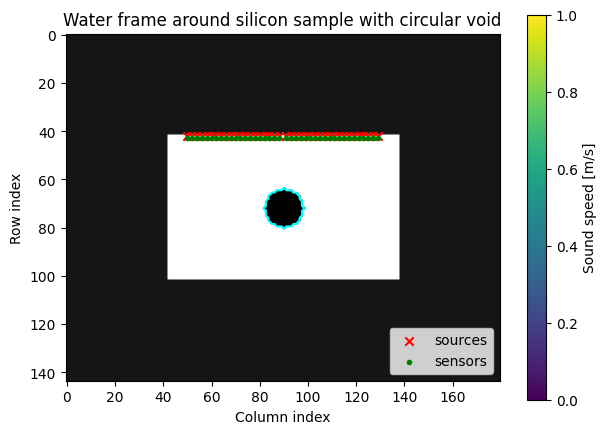

dt = 1.186e-10 s
Total simulation time = 0.356 µs
sample_top: 42
source_row: 42
sensor_row: 43
speed at source row: 8433.0
speed at sensor row: 8433.0
water_speed: 1480.0
si_speed: 8433.0


In [1221]:
# Settings
scale_factor = 20

# Silicon sample size
# sample_N = (60, 96), dx = 5 µm
# Physical size = 300 µm × 480 µm
sample_N = (60, 96)
dx = (5e-6, 5e-6)

# Water frame thickness around all faces of the sample
# About 1/3 of the sample height: 128 / 3 ≈ 42 cells
#water_cells = sample_N[0] // 3

water_cells = 42
# Full simulation domain = water frame + original silicon sample
N = (
    sample_N[0] + 2 * water_cells,
    sample_N[1] + 2 * water_cells,
)

cfl = 0.2
num_sources = 40
source_freq = 1e6 * 1 * scale_factor
# source_mag = 1.3e-5
source_mag = 800.0

random_seed = random.PRNGKey(42)

# Define domain
domain = Domain(N, dx)


# ============================================================
# Define medium: water frame around full-size silicon sample
# ============================================================

water_speed = 1480.0   # m/s, approximate speed of sound in water
si_speed = 8433.0      # m/s, silicon-like speed from your original code

# Silicon sample location inside the larger water domain
sample_top = water_cells
sample_left = water_cells
sample_bottom = sample_top + sample_N[0]
sample_right = sample_left + sample_N[1]

# Start with water everywhere
sound_speed = water_speed * jnp.ones(N)

# Create a silicon sample mask
# 0 = water
# 1 = silicon sample
sample_mask = jnp.zeros(N)
sample_mask = sample_mask.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(1.0)

# Put silicon speed inside the sample region
sound_speed = sound_speed * (1.0 - sample_mask) + si_speed * sample_mask



# ============================================================
# CIRCULAR VOID INSIDE SILICON SAMPLE
# ============================================================
# This creates one circular void inside the silicon sample.
# The mask is saved for future validation.
# Void speed = 8% of the silicon speed.
# ============================================================

# ============================================================
# VOID-SPEED CONTRAST LIMIT TEST
# ============================================================
# Main manual variable:
#
# contrast 10% -> void_speed_fraction = 0.90
# contrast 20% -> void_speed_fraction = 0.80
# contrast 30% -> void_speed_fraction = 0.70
# contrast 40% -> void_speed_fraction = 0.60
# contrast 50% -> void_speed_fraction = 0.50
# contrast 60% -> void_speed_fraction = 0.40
# contrast 70% -> void_speed_fraction = 0.30
#
# The contrast is:
# contrast = 100 * (c_Si - c_void) / c_Si
# ============================================================

void_radius_cells = 8

# Change only this number for each run.
void_speed_fraction = 0.10

void_speed_percent = int(round(100.0 * void_speed_fraction))
void_contrast_fraction = 1.0 - void_speed_fraction
void_contrast_percent = 100.0 * void_contrast_fraction

true_void_speed = si_speed * void_speed_fraction
required_update_for_void = si_speed * void_contrast_fraction

print("void_speed_fraction:", void_speed_fraction)
print("void speed percent of silicon:", void_speed_percent)
print("void contrast percent from silicon:", void_contrast_percent)
print("true void speed [m/s]:", true_void_speed)
print("required update from silicon [m/s]:", required_update_for_void)

# Void center inside the silicon sample
void_center_row = sample_top + sample_N[0] // 2
void_center_col = sample_left + sample_N[1] // 2

# Full-grid coordinates
rows = np.arange(N[0])[:, None]
cols_grid = np.arange(N[1])[None, :]

# Distance from void center
dr = rows - void_center_row
dc = cols_grid - void_center_col
radius_grid = np.sqrt(dr**2 + dc**2)

# Circular void mask
circular_void_mask_np = radius_grid <= void_radius_cells

# Make sure the void exists only inside the silicon sample
circular_void_mask_np = circular_void_mask_np & np.array(sample_mask).astype(bool)

# Save this mask for future validation
circular_void_mask_for_validation = circular_void_mask_np.copy()

# Convert mask to JAX
circular_void_mask = jnp.array(circular_void_mask_np).astype(jnp.float32)

# Apply circular void speed
# Inside the void: speed = void_speed_fraction × silicon speed
# Outside the void: unchanged
sound_speed = sound_speed * (1.0 - circular_void_mask) + (
    void_speed_fraction * sound_speed
) * circular_void_mask

# Convert the sound-speed map into a j-wave FourierSeries field
sound_speed = FourierSeries(jnp.expand_dims(sound_speed, -1), domain)

medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8.0)


# ============================================================
# Time axis
# ============================================================

time_axis = TimeAxis.from_medium(medium, cfl=cfl)

# Force a long time window, as in your reference figure
n_steps = 3000
time_axis = TimeAxis(dt=time_axis.dt, t_end=n_steps * time_axis.dt)
t = time_axis.to_array()


# ============================================================
# Source signal
# ============================================================

s1 = source_mag * jnp.sin(2 * jnp.pi * source_freq * t)

# Pulse position to avoid shift
center_index = 200
center_time = center_index * time_axis.dt

# Gaussian pulse width
#sigma_time = 24e-9
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)


# ============================================================
# Sources and sensors directly at the sample surface
# ============================================================

num_sensors = num_sources  # 80 sensors because num_sources = 80

# The silicon sample starts at row sample_top.
# sample_top - 1 is the last water row before the silicon.
# This places the sources and sensors directly above the sample surface,
# but still inside the surrounding water.
source_row = sample_top 
sensor_row = sample_top + 1

# Horizontally, place sources/sensors across the silicon sample width.
# We avoid the exact sample edges by using an 8-cell margin inside the sample width.
cols = jnp.linspace(
    sample_left + 8,
    sample_right - 9,
    num_sources
).round().astype(int)

source_positions = (
    jnp.full((num_sources,), source_row, dtype=int),
    cols,
)

sensors_positions = (
    jnp.full((num_sensors,), sensor_row, dtype=int),
    cols,
)

sensors = Sensors(positions=sensors_positions)


# ============================================================
# Optional: visualize the new setup
# ============================================================

plt.figure(figsize=(7, 5))
plt.imshow(medium.sound_speed.on_grid[..., 0], cmap="gray")

plt.contour(
    circular_void_mask_for_validation,
    levels=[0.5],
    colors="cyan",
    linewidths=1.5
)

plt.scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)
plt.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)
plt.colorbar(label="Sound speed [m/s]")
plt.legend(loc="lower right")
plt.title("Water frame around silicon sample with circular void")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()


total_time_us = n_steps * time_axis.dt * 1e6
print(f"dt = {time_axis.dt:.3e} s")
print(f"Total simulation time = {total_time_us:.3f} µs")


# ============================================================
# Optional: old circular source/sensor setup
# ============================================================

# x, y = points_on_circle(num_sources, 40, (64, 48))
# source_positions = (jnp.array(x), jnp.array(y))

# sensors_positions = (x, y)
# sensors = Sensors(positions=sensors_positions)

speed_grid = medium.sound_speed.on_grid[..., 0]

print("sample_top:", sample_top)

print("source_row:", source_row)

print("sensor_row:", sensor_row)

print("speed at source row:", float(speed_grid[int(source_row), int(cols[0])]))

print("speed at sensor row:", float(speed_grid[int(sensor_row), int(cols[0])]))

print("water_speed:", water_speed)

print("si_speed:", si_speed)

Text(0.5, 1.0, 'Source signals')

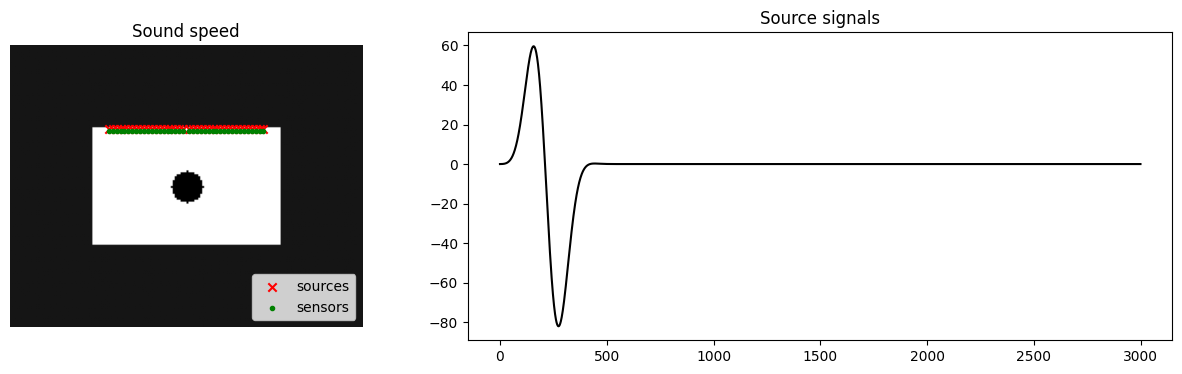

In [1222]:
# Show simulation setup
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(medium.sound_speed.on_grid, cmap="gray")
ax[0].scatter(
    source_positions[1], source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker=".", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source 1", c="k")
ax[1].set_title("Source signals")
#ax[1].get_yaxis().set_visible(False)



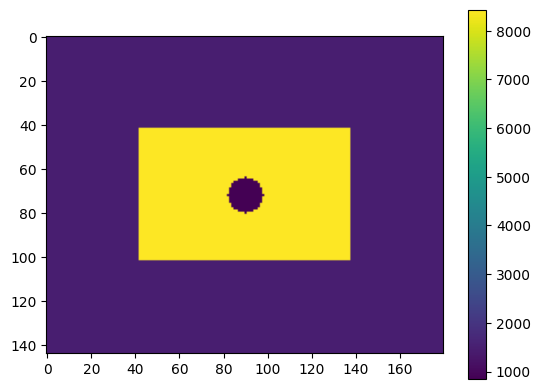

In [1223]:
plt.imshow(medium.sound_speed.on_grid)
plt.colorbar()

In [1224]:
src_signal = jnp.stack([signal])

# We can compile the entire function! All the constructors
# that don't depend on the inputs will be statically compiled
# and run only once.
@jit
def single_source_simulation(sound_speed, source_num):
    # Setting source
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))
    sources = Sources((x, y), src_signal, dt=time_axis.dt, domain=domain)

    # Updating medium with the input speed of sound map
    medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8)

    # Run simulations
    # rf_signals = simulate_wave_propagation(
    #     medium, time_axis, sources=sources, sensors=sensors, checkpoint=True
    # )
    rf_signals = simulate_wave_propagation(
        medium, time_axis, sources=sources, sensors=sensors,
    )
    return rf_signals[..., 0]

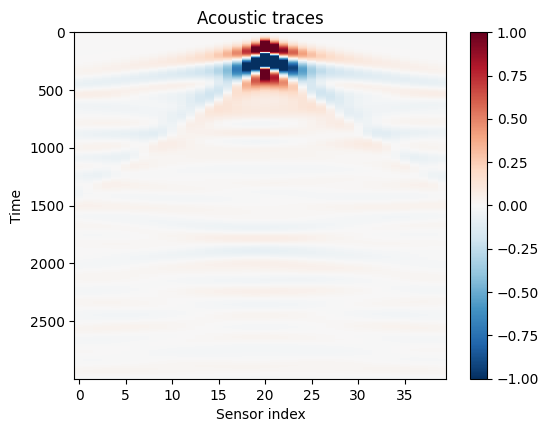

In [1225]:

p = single_source_simulation(medium.sound_speed, 20)

# Visualize the acoustic traces
plt.figure(figsize=(6, 4.5))
maxval = jnp.amax(jnp.abs(p))
plt.imshow(
    p, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest", aspect="auto"
    
)
plt.colorbar()
plt.title("Acoustic traces")
plt.xlabel("Sensor index")
plt.ylabel("Time")
plt.show()

In [1226]:
print("sample_top:", sample_top)
print("sample_bottom:", sample_bottom)
print("source_row:", source_row)
print("sensor_row:", sensor_row)

if sensor_row < sample_top:
    print("Sensors are in water above the Si sample.")
elif sensor_row >= sample_bottom:
    print("Sensors are below the Si sample.")
else:
    print("Sensors are inside the Si sample.")

speed_grid = medium.sound_speed.on_grid[..., 0]

print("Speed at sensor row, first sensor:",
      speed_grid[int(sensor_row), int(cols[0])])

print("Expected water speed:", water_speed)
print("Expected Si speed:", si_speed)

sample_top: 42
sample_bottom: 102
source_row: 42
sensor_row: 43
Sensors are inside the Si sample.
Speed at sensor row, first sensor: 8433.0
Expected water speed: 1480.0
Expected Si speed: 8433.0


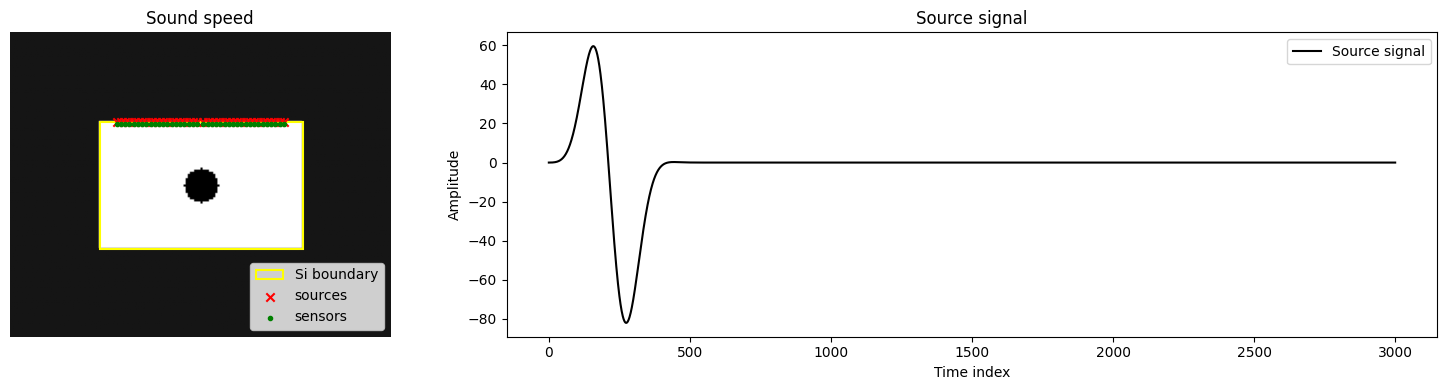

In [1227]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(15, 4),
    gridspec_kw={"width_ratios": [1, 2]}
)

speed_grid = medium.sound_speed.on_grid[..., 0]

ax[0].imshow(speed_grid, cmap="gray")

# Draw silicon sample boundary
rect = plt.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=1.5,
    label="Si boundary"
)
ax[0].add_patch(rect)

ax[0].scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)

ax[0].scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)

ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source signal", c="k")
ax[1].set_title("Source signal")
ax[1].set_xlabel("Time index")
ax[1].set_ylabel("Amplitude")
ax[1].legend()

plt.tight_layout()
plt.show()

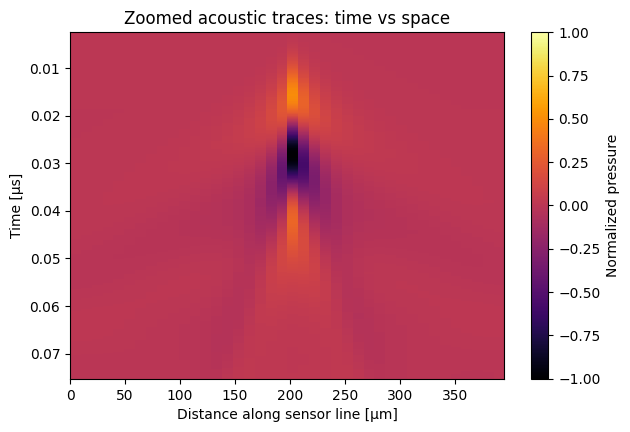

In [1228]:
# ============================================================
# Prepare p
# ============================================================
p_np = np.array(p)
# Make sure shape is time × sensors
if p_np.shape[0] == num_sensors:
    p_np = p_np.T
n_time, n_sensors = p_np.shape
# Normalize
p_norm = p_np / np.nanmax(np.abs(p_np))
# Axes
time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

# ============================================================
# Auto zoom to useful signal
# ============================================================
# Energy per time step
energy_t = np.max(np.abs(p_norm), axis=1)
# Find where signal is visible
zoom_threshold = 0.03
visible_idx = np.where(energy_t > zoom_threshold)[0]
if len(visible_idx) > 0:
    t0_idx = max(0, visible_idx[0] - 20)
    t1_idx = min(n_time - 1, visible_idx[-1] + 40)
else:
    t0_idx = 0
    t1_idx = n_time - 1
time_zoom_us = time_us[t0_idx:t1_idx + 1]
p_zoom = p_norm[t0_idx:t1_idx + 1, :]

# ============================================================
# Plot zoomed time-space diagram
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.imshow(
    p_zoom,
    cmap="inferno",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="auto",
    extent=[
        sensor_x_um[0],
        sensor_x_um[-1],
        time_zoom_us[-1],
        time_zoom_us[0],
    ],
)
plt.colorbar(label="Normalized pressure")
plt.title("Zoomed acoustic traces: time vs space")
plt.xlabel("Distance along sensor line [µm]")
plt.ylabel("Time [µs]")
plt.show()

In [1229]:
# ============================================================
# INDEPENDENT ARRIVAL PICKING + FAST/SLOW ANALYSIS CSV
# No previous arrival-analysis blocks required
# Uses: p, time_axis, cols, dx, num_sensors
# ============================================================



# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

source_index = 20

# Silicon reference speed
reference_speed_m_s = 8433.0

# Arrival picker threshold: 40% of each sensor peak
arrival_fraction = 0.40

# Start searching slightly before the expected Si arrival
safety_margin_us = 0.003

# Classification tolerance
timing_tolerance_ns = 1.0

# Maximum expected speed increase from defects
# circle_1 = +5%, circle_2 = +2%, circle_3 = +3%
# Use 0.10 as conservative maximum if they overlap
max_speed_increase_fraction = 0.10

# Output folder
output_dir = "arrival_analysis_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Convert pressure to numpy and make sure shape is [time, sensors]
# ------------------------------------------------------------

p_np = np.array(p)

if p_np.shape[0] == num_sensors:
    p_np = p_np.T

n_time, n_sensors = p_np.shape

print("p_np shape [time, sensors]:", p_np.shape)

# ------------------------------------------------------------
# Time axis
# ------------------------------------------------------------

time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
time_ns = time_us * 1000.0

print("Total simulation time steps:", n_time)
print("Maximum possible time index:", n_time - 1)
print("dt [ns]:", float(time_axis.dt) * 1e9)
print("Final simulation time [ns]:", time_ns[-1])

# ------------------------------------------------------------
# Sensor positions and distance from source
# ------------------------------------------------------------

sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

source_x_um = sensor_x_um[source_index]
distance_from_source_um = np.abs(sensor_x_um - source_x_um)

print("Source index:", source_index)
print("Source x position [um]:", source_x_um)

# ------------------------------------------------------------
# Hilbert envelope
# ------------------------------------------------------------

def hilbert_transf(signal):
    return np.abs(np.array(analytic_signal(jnp.array(signal))))

p_env = hilbert_transf(p_np)

global_max = np.nanmax(p_env)

# ------------------------------------------------------------
# Initialize arrays
# ------------------------------------------------------------

arrival_idx_full = np.full(n_sensors, np.nan)
arrival_time_full_us = np.full(n_sensors, np.nan)

expected_arrival_us_array = np.full(n_sensors, np.nan)
search_start_us_array = np.full(n_sensors, np.nan)
search_start_idx_array = np.full(n_sensors, np.nan)

arrival_residual_us = np.full(n_sensors, np.nan)
apparent_speed_m_s = np.full(n_sensors, np.nan)
speed_ratio_vs_reference = np.full(n_sensors, np.nan)

sensor_peak = np.full(n_sensors, np.nan)
sensor_peak_fraction_global = np.full(n_sensors, np.nan)

# ------------------------------------------------------------
# Arrival picking
# ------------------------------------------------------------

for s in range(n_sensors):

    trace_env = p_env[:, s]

    local_max = np.nanmax(trace_env)
    sensor_peak[s] = local_max
    sensor_peak_fraction_global[s] = local_max / global_max

    if local_max <= 0 or np.isnan(local_max):
        continue

    # Distance from source in meters
    distance_m = distance_from_source_um[s] * 1e-6

    # Expected arrival time in homogeneous Si
    expected_arrival_us = distance_m / reference_speed_m_s * 1e6
    expected_arrival_us_array[s] = expected_arrival_us

    # Start search slightly before expected arrival
    search_start_us = max(0.0, expected_arrival_us - safety_margin_us)
    search_start_us_array[s] = search_start_us

    search_start_idx = int(np.searchsorted(time_us, search_start_us))
    search_start_idx = min(search_start_idx, n_time - 1)
    search_start_idx_array[s] = search_start_idx

    # Local threshold
    local_threshold = arrival_fraction * local_max

    hits = np.where(trace_env[search_start_idx:] >= local_threshold)[0]

    if len(hits) > 0:
        arrival_idx_full[s] = search_start_idx + hits[0]
        arrival_time_full_us[s] = time_us[int(arrival_idx_full[s])]

    # Residual and apparent speed
    if not np.isnan(arrival_time_full_us[s]):

        arrival_residual_us[s] = arrival_time_full_us[s] - expected_arrival_us

        if distance_m > 0:
            apparent_speed_m_s[s] = distance_m / (arrival_time_full_us[s] * 1e-6)
            speed_ratio_vs_reference[s] = apparent_speed_m_s[s] / reference_speed_m_s

# ------------------------------------------------------------
# Convert to nanoseconds
# ------------------------------------------------------------

arrival_time_ns = arrival_time_full_us * 1000.0
expected_arrival_time_ns = expected_arrival_us_array * 1000.0
arrival_residual_ns = arrival_residual_us * 1000.0
arrival_advance_ns = expected_arrival_time_ns - arrival_time_ns

search_start_time_ns = search_start_us_array * 1000.0

# ------------------------------------------------------------
# Percent changes
# ------------------------------------------------------------

# arrival_residual_percent = (
#     100.0 * arrival_residual_ns / expected_arrival_time_ns
# )

# arrival_advance_percent = (
#     100.0 * arrival_advance_ns / expected_arrival_time_ns
# )

# # Avoid division by zero at source sensor
# arrival_residual_percent[expected_arrival_time_ns == 0] = np.nan
# arrival_advance_percent[expected_arrival_time_ns == 0] = np.nan


# ------------------------------------------------------------
# Percent changes
# Avoid division by zero at the source sensor
# ------------------------------------------------------------

arrival_residual_percent = np.full(n_sensors, np.nan)
arrival_advance_percent = np.full(n_sensors, np.nan)

valid_expected = expected_arrival_time_ns > 0

arrival_residual_percent[valid_expected] = (
    100.0
    * arrival_residual_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)

arrival_advance_percent[valid_expected] = (
    100.0
    * arrival_advance_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)


# ------------------------------------------------------------
# Behavior classification
# Positive advance = faster than expected
# ------------------------------------------------------------

arrival_behavior = np.full(n_sensors, "no_detection", dtype=object)

for s in range(n_sensors):

    if np.isnan(arrival_time_ns[s]):
        arrival_behavior[s] = "no_detection"

    elif arrival_advance_ns[s] > timing_tolerance_ns:
        arrival_behavior[s] = "faster_than_expected"

    elif arrival_advance_ns[s] < -timing_tolerance_ns:
        arrival_behavior[s] = "slower_than_expected"

    else:
        arrival_behavior[s] = "as_expected"

# ------------------------------------------------------------
# Physical diagnostic without t0_source correction
# ------------------------------------------------------------

max_possible_speed_m_s = reference_speed_m_s * (1.0 + max_speed_increase_fraction)

distance_m_all = distance_from_source_um * 1e-6

travel_time_reference_ns = distance_m_all / reference_speed_m_s * 1e9
travel_time_fastest_ns = distance_m_all / max_possible_speed_m_s * 1e9

max_possible_advance_ns = travel_time_reference_ns - travel_time_fastest_ns

advance_excess_ns = arrival_advance_ns - max_possible_advance_ns

advance_is_physically_suspicious = advance_excess_ns > 1.0

# ------------------------------------------------------------
# Create final DataFrame
# ------------------------------------------------------------

arrival_table_direct_first_all_sensors = pd.DataFrame({
    "arrival_type": "direct_first_arrival",
    "sensor_index": np.arange(n_sensors),
    "x_position_um": sensor_x_um,
    "distance_from_source_um": distance_from_source_um,

    # Detected arrival
    "arrival_time_us": arrival_time_full_us,
    "arrival_time_ns": arrival_time_ns,
    "arrival_sample_index": arrival_idx_full,

    # Expected arrival in homogeneous Si
    "expected_arrival_time_us": expected_arrival_us_array,
    "expected_arrival_time_ns": expected_arrival_time_ns,

    # Residual: detected - expected
    # Negative residual = faster than expected
    "arrival_residual_us": arrival_residual_us,
    "arrival_residual_ns": arrival_residual_ns,
    "arrival_residual_percent": arrival_residual_percent,

    # Advance: expected - detected
    # Positive advance = faster than expected
    "arrival_advance_ns": arrival_advance_ns,
    "arrival_advance_percent": arrival_advance_percent,

    # Search-window debug
    "search_start_time_us": search_start_us_array,
    "search_start_time_ns": search_start_time_ns,
    "search_start_index": search_start_idx_array,

    # Speed interpretation
    "reference_speed_m_s": reference_speed_m_s,
    "apparent_speed_m_s": apparent_speed_m_s,
    "speed_ratio_vs_reference": speed_ratio_vs_reference,
    "arrival_behavior": arrival_behavior,

    # Physical diagnostic
    "max_speed_increase_fraction": max_speed_increase_fraction,
    "max_possible_speed_m_s": max_possible_speed_m_s,
    "max_possible_advance_ns": max_possible_advance_ns,
    "advance_excess_ns": advance_excess_ns,
    "advance_is_physically_suspicious": advance_is_physically_suspicious,

    # Picker and signal quality
    "threshold_fraction_of_sensor_peak": arrival_fraction,
    "timing_tolerance_ns": timing_tolerance_ns,
    "sensor_peak_envelope": sensor_peak,
    "sensor_peak_normalized_to_global_max": sensor_peak_fraction_global,
})

# ------------------------------------------------------------
# Save full CSV
# ------------------------------------------------------------

full_csv_path = os.path.join(
    output_dir,
    "arrival_table_direct_first_all_sensors_final_no_t0_correction.csv"
)

arrival_table_direct_first_all_sensors.to_csv(full_csv_path, index=False)

# ------------------------------------------------------------
# Save sorted table: strongest advances first
# ------------------------------------------------------------

advance_sorted_table = arrival_table_direct_first_all_sensors.sort_values(
    "arrival_advance_ns",
    ascending=False
)[[
    "sensor_index",
    "x_position_um",
    "distance_from_source_um",
    "arrival_time_ns",
    "expected_arrival_time_ns",
    "arrival_advance_ns",
    "arrival_advance_percent",
    "max_possible_advance_ns",
    "advance_excess_ns",
    "advance_is_physically_suspicious",
    "speed_ratio_vs_reference",
    "arrival_behavior"
]]

sorted_csv_path = os.path.join(
    output_dir,
    "arrival_advance_sorted_no_t0_correction.csv"
)

advance_sorted_table.to_csv(sorted_csv_path, index=False)

# ------------------------------------------------------------
# Display and summary
# ------------------------------------------------------------

display(arrival_table_direct_first_all_sensors)
display(advance_sorted_table)

print("Saved full CSV:", full_csv_path)
print("Saved sorted CSV:", sorted_csv_path)
print("Total sensors:", n_sensors)
print("Valid arrivals:", np.sum(~np.isnan(arrival_time_ns)))
print("Missing arrivals:", np.sum(np.isnan(arrival_time_ns)))
print("Faster than expected:", np.sum(arrival_behavior == "faster_than_expected"))
print("As expected:", np.sum(arrival_behavior == "as_expected"))
print("Slower than expected:", np.sum(arrival_behavior == "slower_than_expected"))
print("Physically suspicious:", np.sum(advance_is_physically_suspicious))

p_np shape [time, sensors]: (3000, 40)
Total simulation time steps: 3000
Maximum possible time index: 2999
dt [ns]: 0.11858175552603711
Final simulation time [ns]: 355.6266848225853
Source index: 20
Source x position [um]: 205.00000000000006


,arrival_type,sensor_index,x_position_um,distance_from_source_um,arrival_time_us,arrival_time_ns,arrival_sample_index,expected_arrival_time_us,expected_arrival_time_ns,arrival_residual_us,...,arrival_behavior,max_speed_increase_fraction,max_possible_speed_m_s,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,threshold_fraction_of_sensor_peak,timing_tolerance_ns,sensor_peak_envelope,sensor_peak_normalized_to_global_max
0,direct_first_arrival,0,0.0,205.0,0.021345,21.344716,180.0,0.024309,24.309261,-0.002965,...,faster_than_expected,0.1,9276.3,2.209933,0.754612,False,0.4,1.0,0.288429,0.058737
1,direct_first_arrival,1,10.0,195.0,0.020159,20.158898,170.0,0.023123,23.123444,-0.002965,...,faster_than_expected,0.1,9276.3,2.102131,0.862414,False,0.4,1.0,0.306397,0.062396
2,direct_first_arrival,2,20.0,185.0,0.018973,18.973081,160.0,0.021938,21.937626,-0.002965,...,faster_than_expected,0.1,9276.3,1.994330,0.970215,False,0.4,1.0,0.301308,0.061360
3,direct_first_arrival,3,30.0,175.0,0.017787,17.787263,150.0,0.020752,20.751808,-0.002965,...,faster_than_expected,0.1,9276.3,1.886528,1.078017,True,0.4,1.0,0.320833,0.065336
4,direct_first_arrival,4,40.0,165.0,0.016601,16.601446,140.0,0.019566,19.565991,-0.002965,...,faster_than_expected,0.1,9276.3,1.778726,1.185819,True,0.4,1.0,0.325395,0.066265
5,direct_first_arrival,5,50.0,155.0,0.015416,15.415628,130.0,0.018380,18.380173,-0.002965,...,faster_than_expected,0.1,9276.3,1.670925,1.293620,True,0.4,1.0,0.349083,0.071089
6,direct_first_arrival,6,60.0,145.0,0.014230,14.229811,120.0,0.017194,17.194356,-0.002965,...,faster_than_expected,0.1,9276.3,1.563123,1.401422,True,0.4,1.0,0.362737,0.073869
7,direct_first_arrival,7,70.0,135.0,0.013044,13.043993,110.0,0.016009,16.008538,-0.002965,...,faster_than_expected,0.1,9276.3,1.455322,1.509223,True,0.4,1.0,0.395010,0.080442
8,direct_first_arrival,8,80.0,125.0,0.014348,14.348392,121.0,0.014823,14.822720,-0.000474,...,as_expected,0.1,9276.3,1.347520,-0.873192,False,0.4,1.0,0.414619,0.084435
9,direct_first_arrival,9,90.0,115.0,0.012807,12.806830,108.0,0.013637,13.636903,-0.000830,...,as_expected,0.1,9276.3,1.239718,-0.409645,False,0.4,1.0,0.463770,0.094444


,sensor_index,x_position_um,distance_from_source_um,arrival_time_ns,expected_arrival_time_ns,arrival_advance_ns,arrival_advance_percent,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,speed_ratio_vs_reference,arrival_behavior
0,0,0.0,205.0,21.344716,24.309261,2.964545,12.195127,2.209933,0.754612,False,1.138889,faster_than_expected
1,1,10.0,195.0,20.158898,23.123444,2.964545,12.820518,2.102131,0.862414,False,1.147059,faster_than_expected
39,39,395.0,190.0,19.565990,22.530535,2.964545,13.157900,2.048230,0.916315,False,1.151515,faster_than_expected
2,2,20.0,185.0,18.973081,21.937626,2.964545,13.513518,1.994330,0.970215,False,1.156250,faster_than_expected
38,38,385.0,180.0,18.380172,21.344717,2.964545,13.888894,1.940429,1.024116,True,1.161290,faster_than_expected
3,3,30.0,175.0,17.787263,20.751808,2.964545,14.285719,1.886528,1.078017,True,1.166667,faster_than_expected
37,37,375.0,170.0,17.194355,20.158900,2.964545,14.705887,1.832627,1.131918,True,1.172414,faster_than_expected
4,4,40.0,165.0,16.601446,19.565991,2.964545,15.151520,1.778726,1.185819,True,1.178571,faster_than_expected
36,36,365.0,160.0,16.008537,18.973082,2.964545,15.625005,1.724826,1.239719,True,1.185185,faster_than_expected
5,5,50.0,155.0,15.415628,18.380173,2.964545,16.129037,1.670925,1.293620,True,1.192308,faster_than_expected


Saved full CSV: arrival_analysis_outputs/arrival_table_direct_first_all_sensors_final_no_t0_correction.csv
Saved sorted CSV: arrival_analysis_outputs/arrival_advance_sorted_no_t0_correction.csv
Total sensors: 40
Valid arrivals: 40
Missing arrivals: 0
Faster than expected: 15
As expected: 4
Slower than expected: 21
Physically suspicious: 10


In [1230]:
batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))
p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))
print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

Size of data [Source idx, Time, Sensor idx]: (40, 3000, 40)


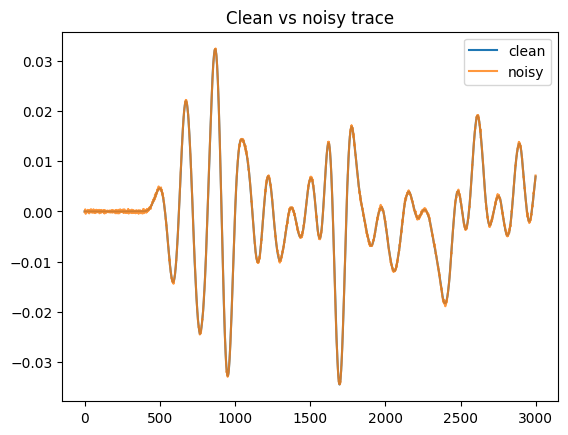

In [1231]:
# ============================================================
# ADD PER-TRACE RELATIVE NOISE + CLEAN/NOISY COMPARISON
# Old variable names preserved
# ============================================================

p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))

noise_level = 0.005

p_clean = np.array(p_data)

trace_scale = np.max(np.abs(p_clean), axis=1, keepdims=True)
trace_scale[trace_scale == 0] = 1.0

noise = np.random.normal(size=p_clean.shape) * noise_level * trace_scale

p_data = jnp.array(p_clean + noise)

plt.plot(p_clean[39, :, 0], label="clean")
plt.plot(p_data[39, :, 0], label="noisy", alpha=0.8)
plt.title("Clean vs noisy trace")
plt.legend()
plt.show()

In [1232]:


# ============================================================
# Background model for inversion
# Water frame + homogeneous silicon sample
# No tectonic layer in the initial model
# ============================================================

background_speed_grid = water_speed * jnp.ones(N)

background_speed_grid = background_speed_grid.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(si_speed)

background_speed = FourierSeries(
    jnp.expand_dims(background_speed_grid, -1),
    domain
)


# ============================================================
# Inversion mask
# Only allow updates inside the silicon sample
# Keep a small margin away from sample boundaries
# ============================================================

margin = 4

mask_grid = jnp.zeros(N)

mask_grid = mask_grid.at[
    sample_top + margin : sample_bottom - margin,
    sample_left + margin : sample_right - margin
].set(1.0)

mask = FourierSeries(
    jnp.expand_dims(mask_grid, -1),
    domain
)



# ============================================================
# CONTRAST-LIMIT BENCHMARK SETTING
# ============================================================
# For this study, we are NOT testing max-update range.
# We are testing how far the void speed can be from silicon
# before FWI reconstruction quality breaks down.
#
# Therefore:
# max_velocity_update = required_update_for_void
#
# This gives the inversion enough range to represent the true void.
# If it still fails, the failure is from the FWI method/configuration,
# not from an insufficient update range.
# ============================================================

required_update_for_void = si_speed * (1.0 - void_speed_fraction)

max_velocity_update = required_update_for_void

print("CONTRAST-LIMIT BENCHMARK")
print("void_speed_fraction:", void_speed_fraction)
print("void speed percent of silicon:", 100.0 * void_speed_fraction)
print("void contrast percent from silicon:", 100.0 * (1.0 - void_speed_fraction))
print("true void speed [m/s]:", si_speed * void_speed_fraction)
print("required update for void [m/s]:", required_update_for_void)
print("max_velocity_update [m/s]:", max_velocity_update)
print("max update percent of silicon:", 100.0 * max_velocity_update / si_speed)
print(
    "theoretical max recovery percent:",
    min(100.0, 100.0 * max_velocity_update / required_update_for_void)
)







def get_sound_speed(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    return background_speed + velocity_update


# Initial params = 0 gives tanh(0) = 0
# Therefore initial inversion model = background_speed exactly
params = medium.sound_speed * 0.0

CONTRAST-LIMIT BENCHMARK
void_speed_fraction: 0.1
void speed percent of silicon: 10.0
void contrast percent from silicon: 90.0
true void speed [m/s]: 843.3000000000001
required update for void [m/s]: 7589.7
max_velocity_update [m/s]: 7589.7
max update percent of silicon: 90.0
theoretical max recovery percent: 100.0


Initial speed outside sample:
1480.0
Initial speed inside sample:
8433.0
Expected water speed: 1480.0
Expected silicon speed: 8433.0


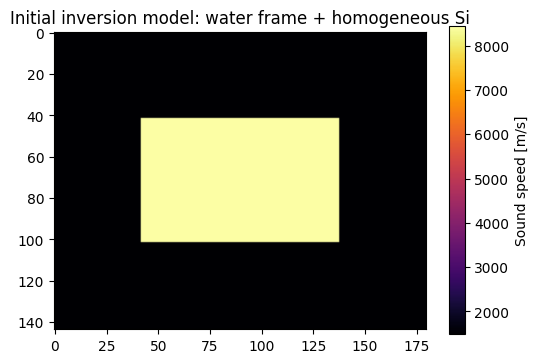

In [1233]:
# ============================================================
# Verify the initial inversion model
# ============================================================

initial_sos = get_sound_speed(params).on_grid[..., 0]

print("Initial speed outside sample:")
print(float(initial_sos[0, 0]))

print("Initial speed inside sample:")
print(float(initial_sos[sample_top + 10, sample_left + 10]))

print("Expected water speed:", water_speed)
print("Expected silicon speed:", si_speed)

plt.figure(figsize=(6, 4))
plt.imshow(initial_sos, cmap="inferno")
plt.colorbar(label="Sound speed [m/s]")
plt.title("Initial inversion model: water frame + homogeneous Si")
plt.show()

In [1234]:
# ============================================================
# Smoothness regularization
# Penalizes rough spatial variations in the inversion parameters
# ============================================================

regularization_weight = 1e-5
vertical_weight = 3.0
horizontal_weight = 1.0


def smoothness_regularization(params):
    p = params.on_grid[..., 0]

    vertical_diff = p[1:, :] - p[:-1, :]
    horizontal_diff = p[:, 1:] - p[:, :-1]

    reg = (
        vertical_weight * jnp.mean(vertical_diff ** 2)
        + horizontal_weight * jnp.mean(horizontal_diff ** 2)
    )

    return regularization_weight * reg


In [1235]:
# ============================================================
# Optional: Penalize negative velocity updates
# Use only when you know the target anomaly should be faster
# than the background.
#
# WARNING:
# If the sample may contain voids, cracks, pores, or slow defects,
# this can hide the real defect. For void detection, set:
#     use_negative_update_penalty = False
# ============================================================

use_negative_update_penalty = False

negative_update_weight = 5e-7


def negative_update_regularization(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    update_grid = velocity_update.on_grid[..., 0]

    # Keep only negative updates.
    # Positive updates become 0.
    negative_part = jnp.minimum(update_grid, 0.0)

    return negative_update_weight * jnp.mean(negative_part ** 2)

In [1236]:
# ============================================================
# LOSS FUNCTION SELECTION
# Change only loss_name to test different losses
# ============================================================




# Choose one:
# "mse"
# "envelope_mse"
# "normalized_l2"
# "global_normalized_mse"
# "trace_normalized_mse"
# "cross_correlation"
# "tracewise_cross_correlation"
# "log_envelope"
# "phase"
# "time_derivative_mse"
# "wasserstein_1d"
# "amplitude_envelope"
# "hybrid"

loss_name = "amplitude_envelope"


# ============================================================
# Helper functions
# ============================================================

def hilbert_transf(signal, noise=0.2):
    """
    Original envelope transform used in your code.
    """
    x = jnp.abs(analytic_signal(signal))
    return x


def safe_norm(x, eps=1e-8):
    return jnp.sqrt(jnp.sum(x ** 2) + eps)


def normalize_global(data, eps=1e-8):
    return data / (jnp.max(jnp.abs(data)) + eps)


def normalize_traces(data, eps=1e-8):
    """
    Normalize along time axis.

    In your code, p seems to have shape:
        time, sensors, maybe components

    So time is probably axis=0.
    """
    return data / (jnp.max(jnp.abs(data), axis=0, keepdims=True) + eps)


def time_derivative(data, dt):
    """
    Time derivative along time axis.
    """
    return (data[1:, ...] - data[:-1, ...]) / dt


# ============================================================
# Individual loss functions
# ============================================================

def mse_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data
    return 0.5 * jnp.mean(residual ** 2)


def envelope_mse_loss(predicted_data, observed_data, eps=1e-8):
    """
    This is closest to your current loss.
    """
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    residual = predicted_env - observed_env

    return 0.5 * jnp.mean(residual ** 2)


def normalized_l2_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data

    numerator = jnp.sum(residual ** 2)
    denominator = jnp.sum(observed_data ** 2) + eps

    return 0.5 * numerator / denominator


def global_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_global(predicted_data, eps)
    observed_n = normalize_global(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def trace_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_traces(predicted_data, eps)
    observed_n = normalize_traces(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    predicted_flat = predicted_data.reshape(-1)
    observed_flat = observed_data.reshape(-1)

    predicted_flat = predicted_flat - jnp.mean(predicted_flat)
    observed_flat = observed_flat - jnp.mean(observed_flat)

    numerator = jnp.sum(predicted_flat * observed_flat)

    denominator = (
        safe_norm(predicted_flat, eps)
        * safe_norm(observed_flat, eps)
    )

    corr = numerator / denominator

    return 1.0 - corr


def tracewise_cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    """
    Trace-wise correlation.

    Assumes time axis is axis=0.
    """
    predicted_zm = predicted_data - jnp.mean(
        predicted_data,
        axis=0,
        keepdims=True
    )

    observed_zm = observed_data - jnp.mean(
        observed_data,
        axis=0,
        keepdims=True
    )

    numerator = jnp.sum(predicted_zm * observed_zm, axis=0)

    denominator = (
        jnp.sqrt(jnp.sum(predicted_zm ** 2, axis=0) + eps)
        * jnp.sqrt(jnp.sum(observed_zm ** 2, axis=0) + eps)
    )

    corr_per_trace = numerator / denominator

    return 1.0 - jnp.mean(corr_per_trace)


def log_envelope_loss(predicted_data, observed_data, eps=1e-8):
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    predicted_log = jnp.log(predicted_env + eps)
    observed_log = jnp.log(observed_env + eps)

    residual = predicted_log - observed_log

    return 0.5 * jnp.mean(residual ** 2)


def phase_loss(predicted_data, observed_data, eps=1e-8):
    predicted_analytic = analytic_signal(predicted_data)
    observed_analytic = analytic_signal(observed_data)

    predicted_phase = jnp.angle(predicted_analytic)
    observed_phase = jnp.angle(observed_analytic)

    phase_difference = predicted_phase - observed_phase

    phase_residual = jnp.angle(jnp.exp(1j * phase_difference))

    return 0.5 * jnp.mean(phase_residual ** 2)


def time_derivative_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_dt = time_derivative(predicted_data, time_axis.dt)
    observed_dt = time_derivative(observed_data, time_axis.dt)

    residual = predicted_dt - observed_dt

    return 0.5 * jnp.mean(residual ** 2)


def positive_normalized_density(data, eps=1e-8):
    density = data ** 2
    density = density + eps

    density = density / jnp.sum(
        density,
        axis=0,
        keepdims=True
    )

    return density


def wasserstein_1d_loss(predicted_data, observed_data, eps=1e-8):
    predicted_density = positive_normalized_density(predicted_data, eps)
    observed_density = positive_normalized_density(observed_data, eps)

    predicted_cdf = jnp.cumsum(predicted_density, axis=0)
    observed_cdf = jnp.cumsum(observed_density, axis=0)

    residual = predicted_cdf - observed_cdf

    return jnp.mean(jnp.abs(residual))


def amplitude_envelope_loss(predicted_data, observed_data, eps=1e-8):
    alpha = 0.7

    waveform_part = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    envelope_part = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return alpha * waveform_part + (1.0 - alpha) * envelope_part


def hybrid_fwi_loss(predicted_data, observed_data, eps=1e-8):
    w_mse = 0.4
    w_corr = 0.3
    w_env = 0.2
    w_deriv = 0.1

    loss_mse = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_corr = tracewise_cross_correlation_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_env = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_deriv = time_derivative_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return (
        w_mse * loss_mse
        + w_corr * loss_corr
        + w_env * loss_env
        + w_deriv * loss_deriv
    )


# ============================================================
# Loss selector
# ============================================================

def selected_loss(predicted_data, observed_data):
    if loss_name == "mse":
        return mse_loss(predicted_data, observed_data)

    elif loss_name == "envelope_mse":
        return envelope_mse_loss(predicted_data, observed_data)

    elif loss_name == "normalized_l2":
        return normalized_l2_loss(predicted_data, observed_data)

    elif loss_name == "global_normalized_mse":
        return global_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "trace_normalized_mse":
        return trace_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "cross_correlation":
        return cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "tracewise_cross_correlation":
        return tracewise_cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "log_envelope":
        return log_envelope_loss(predicted_data, observed_data)

    elif loss_name == "phase":
        return phase_loss(predicted_data, observed_data)

    elif loss_name == "time_derivative_mse":
        return time_derivative_mse_loss(predicted_data, observed_data)

    elif loss_name == "wasserstein_1d":
        return wasserstein_1d_loss(predicted_data, observed_data)

    elif loss_name == "amplitude_envelope":
        return amplitude_envelope_loss(predicted_data, observed_data)

    elif loss_name == "hybrid":
        return hybrid_fwi_loss(predicted_data, observed_data)

    else:
        raise ValueError(f"Unknown loss_name: {loss_name}")


# ============================================================
# Main loss function used by value_and_grad
# ============================================================

def loss_func(params, source_num):
    c0 = get_sound_speed(params)

    predicted_data = single_source_simulation(c0, source_num)

    observed_data = p_data[source_num]

    loss = selected_loss(
        predicted_data,
        observed_data
    )
    reg_loss = smoothness_regularization(params)
    loss = loss + reg_loss
    # Optional prior: discourage negative velocity updates
    if use_negative_update_penalty:
        loss = loss + negative_update_regularization(params)
    return loss


loss_with_grad = value_and_grad(loss_func, argnums=0)

print("Using loss function:", loss_name)
print("Regularization weight:", regularization_weight)

Using loss function: amplitude_envelope
Regularization weight: 1e-05


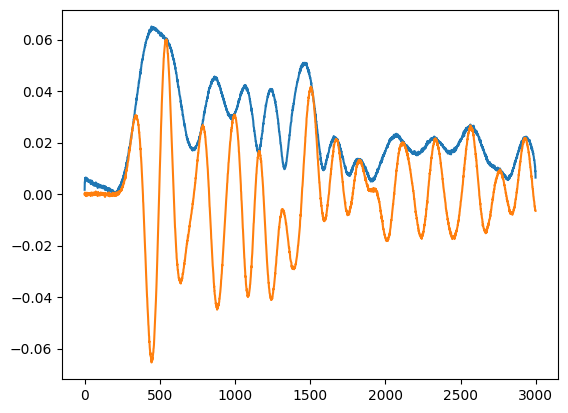

In [1237]:
plt.plot(hilbert_transf(p_data[20, :, 0]))
plt.plot(p_data[20, :, 0])
plt.show()

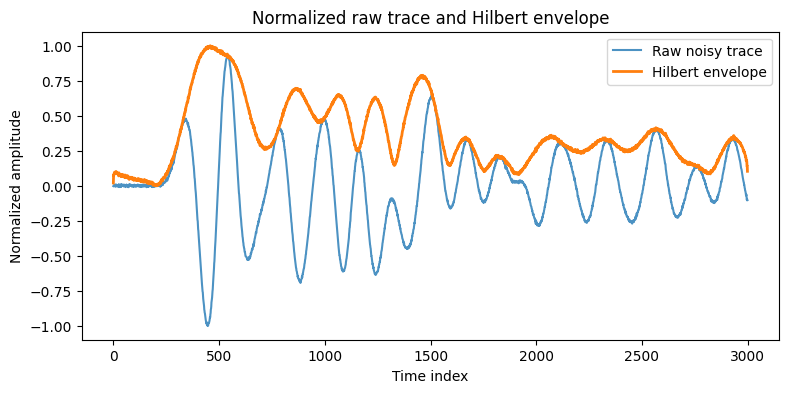

In [1238]:
# ============================================================
# CHECK RAW TRACE + HILBERT ENVELOPE AFTER NOISE
# ============================================================

sensor_id = 20
source_id = 0

raw_trace = np.array(p_data[source_id, :,sensor_id])
env_trace = np.abs(np.array(analytic_signal(jnp.array(raw_trace))))

# Normalize only for visualization
raw_trace_norm = raw_trace / np.max(np.abs(raw_trace))
env_trace_norm = env_trace / np.max(env_trace)

plt.figure(figsize=(9, 4))
plt.plot(raw_trace_norm, label="Raw noisy trace", alpha=0.8)
plt.plot(env_trace_norm, label="Hilbert envelope", linewidth=2)
plt.title("Normalized raw trace and Hilbert envelope")
plt.xlabel("Time index")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.show()

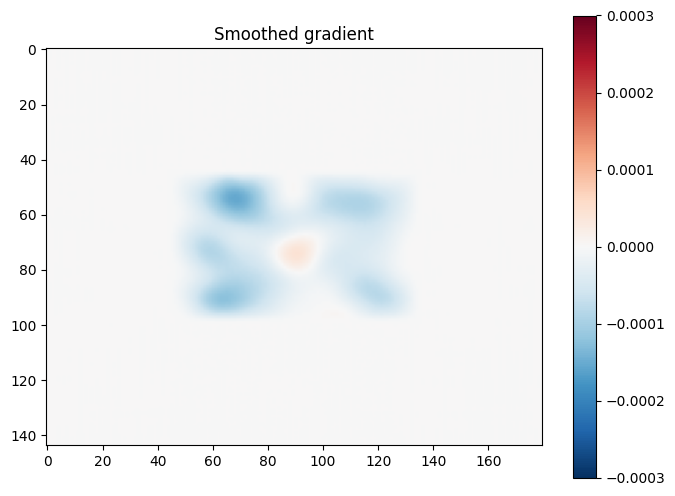

In [1239]:
def smooth_fun(gradient):
    x = gradient.on_grid[..., 0]
    x = smooth(x)
    return gradient.replace_params(jnp.expand_dims(x, -1))

loss, gradient = loss_with_grad(params, source_num=10)
gradient = smooth_fun(gradient)

# Viualize
plt.figure(figsize=(8, 6))
plt.imshow(gradient.on_grid, cmap="RdBu_r", vmin=-0.0003, vmax=0.0003)
plt.title("Smoothed gradient")
plt.colorbar()
plt.show()

In [1240]:
# ============================================================
# Validation loss over fixed sources
# ============================================================

validation_sources = jnp.array([0, 5, 10, 15, 20, 25, 30, 35])


def validation_loss(params):
    losses = []

    for src in validation_sources:
        loss_src = loss_func(params, int(src))
        losses.append(loss_src)

    return jnp.mean(jnp.array(losses))

In [1241]:
losshistory = []
validation_losshistory = []
reconstructions = []
grad_mean_history = []
grad_min_history = []
grad_max_history = []
num_steps = 50
learning_rate = 0.03
sources_per_update = 4

# Define optimizer
init_fun, update_fun, get_params = optimizers.adam(learning_rate, 0.9, 0.9)
opt_state = init_fun(params)


# ============================================================
# Multi-source mini-batch update
# Average gradients from several random laser-shot positions
# ============================================================

@jit
def update(opt_state, key, k):
    v = get_params(opt_state)
    # Choose several source positions for this update
    src_nums = random.choice(
        key,
        num_sources,
        shape=(sources_per_update,),
        replace=False
    )
    # Initial accumulators
    loss_sum = 0.0
    grad_grid_sum = jnp.zeros_like(v.on_grid)
    # Loop over selected sources
    for i in range(sources_per_update):
        src_num = src_nums[i]
        loss_i, grad_i = loss_with_grad(v, src_num)
        loss_sum = loss_sum + loss_i
        grad_grid_sum = grad_grid_sum + grad_i.on_grid
    # Average loss and gradient
    lossval = loss_sum / sources_per_update
    gradient_grid = grad_grid_sum / sources_per_update
    # Convert averaged gradient grid back to FourierSeries
    gradient = FourierSeries(
        gradient_grid,
        domain
    )
    # Diagnostics
    grad_min = jnp.min(gradient_grid)
    grad_max = jnp.max(gradient_grid)
    grad_mean = jnp.mean(jnp.abs(gradient_grid))
    # Keep smoothing OFF for this test
    # gradient = smooth_fun(gradient)
    return lossval, update_fun(k, gradient, opt_state), grad_min, grad_max, grad_mean

print("Stage 1 optimizer and update() are ready.")



Stage 1 optimizer and update() are ready.


In [1242]:

# Main loop
pbar = tqdm(range(num_steps))
_, key = random.split(random_seed)

for k in pbar:
    _, key = random.split(key)
    
    #lossval, opt_state = update(opt_state, key, k)
    lossval, opt_state, grad_min, grad_max, grad_mean = update(
        opt_state,
        key,
        k
    )

    
    ## For logging
    new_params = get_params(opt_state)
    
    reconstructions.append(get_sound_speed(new_params).on_grid)
    
    losshistory.append(float(lossval))
    grad_min_history.append(float(grad_min))
    grad_max_history.append(float(grad_max))
    grad_mean_history.append(float(grad_mean))
    
    # Validation loss every 5 steps

    validation_every = 10
    if k % validation_every == 0:

        val_loss = validation_loss(new_params)
        validation_losshistory.append(float(val_loss))

    else:

        validation_losshistory.append(validation_losshistory[-1])
    

    pbar.set_description(
        "Train loss: {:.6f}, Val loss: {:.6f}, Grad mean: {:.3e}".format(
            float(lossval),
            validation_losshistory[-1],
            float(grad_mean)
        )
    )

Train loss: 0.007829, Val loss: 0.008034, Grad mean: 1.547e-06: 100%|█████| 50/50 [45:09<00:00, 54.20s/it]


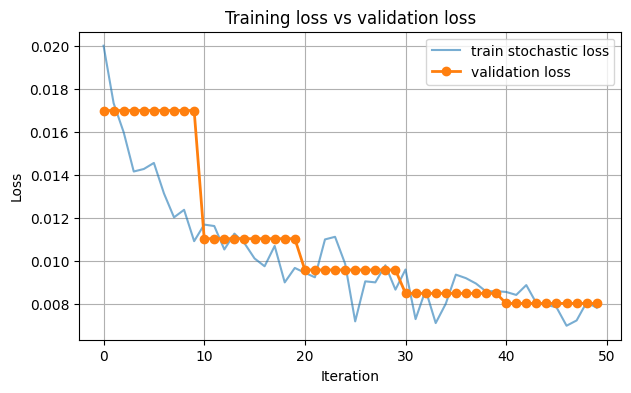

In [1243]:
# ============================================================
# Plot training loss and validation loss
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss",
    alpha=0.6
)

plt.plot(
    validation_losshistory,
    label="validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

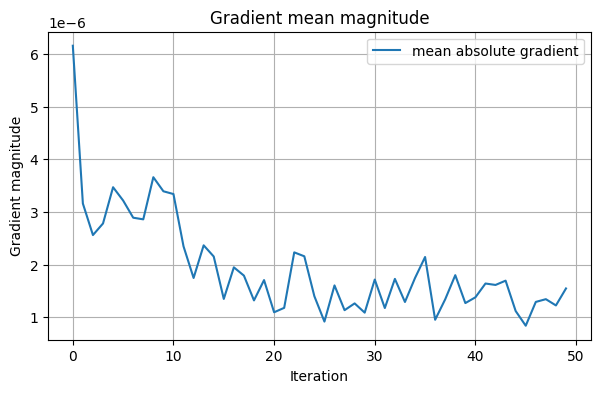

In [1244]:
# ============================================================
# Plot gradient diagnostics
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    grad_mean_history,
    label="mean absolute gradient"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient magnitude")
plt.title("Gradient mean magnitude")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_32620/2826385703.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


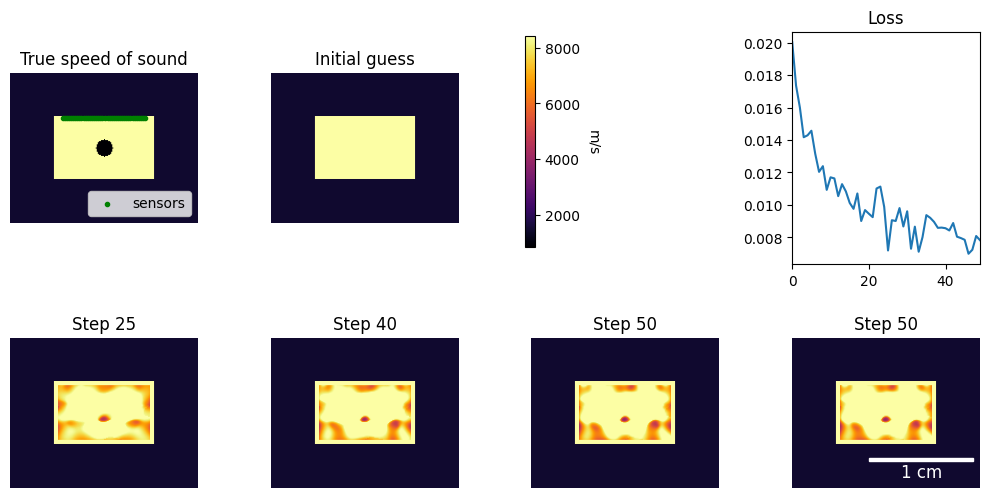

In [1245]:
sos_original = get_sound_speed(params).on_grid
true_sos = sound_speed.on_grid
vmin = np.amin(true_sos)
vmax = np.amax(true_sos)

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))

k = 0
#recs = [24, 39, 69, 99]
recs = [24, 39, 49, 49]
for row in range(2):
    for col in range(4):
        if k == 0:
            axes[row, col].imshow(true_sos, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].scatter(
                sensors_positions[1],
                sensors_positions[0],
                c="g",
                marker=".",
                label="sensors",
            )
            axes[row, col].legend(loc="lower right")
            axes[row, col].set_title("True speed of sound")
            axes[row, col].set_axis_off()
        elif k == 1:
            im_original = axes[row, col].imshow(sos_original, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Initial guess")
            
            cbar_ax = fig.add_axes([0.53, 0.54, 0.01, 0.385])
            cbar = plt.colorbar(im_original, cax=cbar_ax)
            cbar.ax.get_yaxis().labelpad = 15
            cbar.ax.set_ylabel('m/s', rotation=270)
        elif k == 2:
            axes[row, col].set_axis_off()
        elif k == 3:
            axes[row, col].plot(losshistory)
            axes[row, col].set_title("Loss")
            #axes[row, col].set_xticks([], [])
            axes[row, col].margins(x=0)
        else:
            axes[row, col].imshow(reconstructions[recs[k - 4]], cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Step {}".format(recs[k - 4] + 1))
        k += 1

# Scale bar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(
    axes[-1, -1].transData,
    100, '1 cm', 'lower right', 
    pad=0.3,
    color='white',
    frameon=False,
    size_vertical=2,
    fontproperties=fontprops)
axes[-1, -1].add_artist(scalebar)
        
fig.tight_layout()

plt.savefig('fwi.pdf')

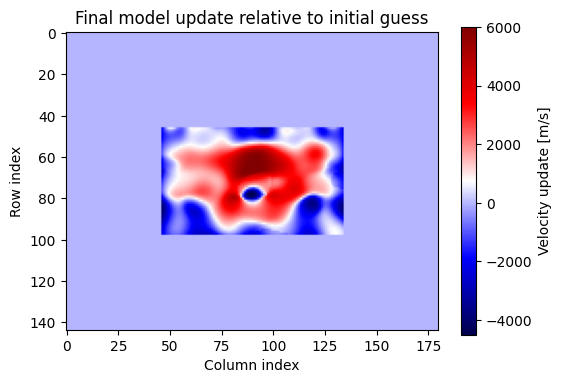

In [1246]:
# ============================================================
# Plot model update relative to initial guess
# ============================================================

initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

model_update = final_sos - initial_sos

plt.figure(figsize=(6, 4))
plt.imshow(model_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

In [1247]:
initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

print("Min update:", float(jnp.min(final_sos - initial_sos)))
print("Max update:", float(jnp.max(final_sos - initial_sos)))
print("Mean abs update:", float(jnp.mean(jnp.abs(final_sos - initial_sos))))

Min update: -4506.7392578125
Max update: 6000.197265625
Mean abs update: 337.97137451171875


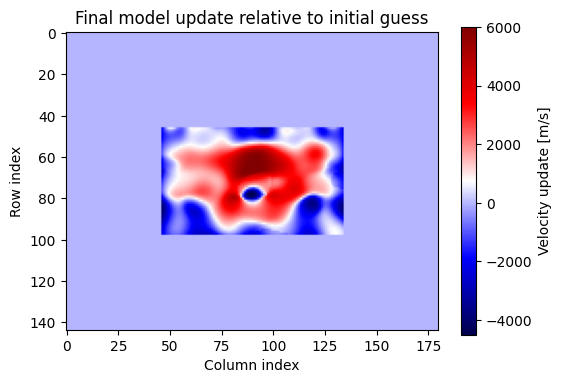

In [1248]:
# ============================================================
# Plot final model update relative to initial guess
# ============================================================

plt.figure(figsize=(6, 4))

plt.imshow(
    model_update,
    cmap="seismic"
)

plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

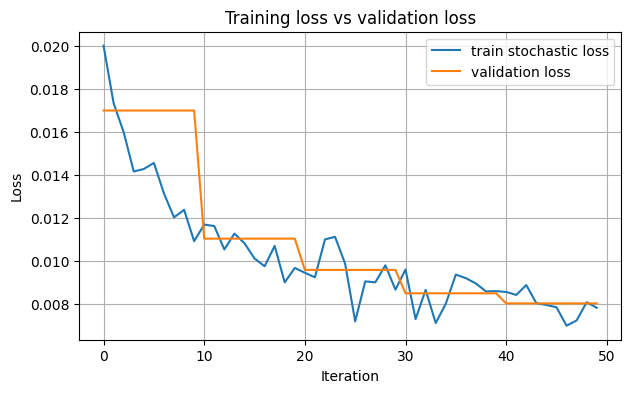

In [1249]:

# ============================================================
# Plot training loss and validation loss separately
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss"
)

plt.plot(
    validation_losshistory,
    label="validation loss"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [1250]:
initial_sos = get_sound_speed(params).on_grid[..., 0]
final_sos = get_sound_speed(get_params(opt_state)).on_grid[..., 0]

model_update = final_sos - initial_sos

print("Sources per update:", sources_per_update)
print("Learning rate:", learning_rate)
print("Num steps:", num_steps)
print("Initial validation loss:", validation_losshistory[0])
print("Final validation loss:", validation_losshistory[-1])
print("Min update:", float(jnp.min(model_update)))
print("Max update:", float(jnp.max(model_update)))
print("Mean abs update:", float(jnp.mean(jnp.abs(model_update))))

Sources per update: 4
Learning rate: 0.03
Num steps: 50
Initial validation loss: 0.017010236158967018
Final validation loss: 0.008034048601984978
Min update: -4506.7392578125
Max update: 6000.197265625
Mean abs update: 337.97137451171875


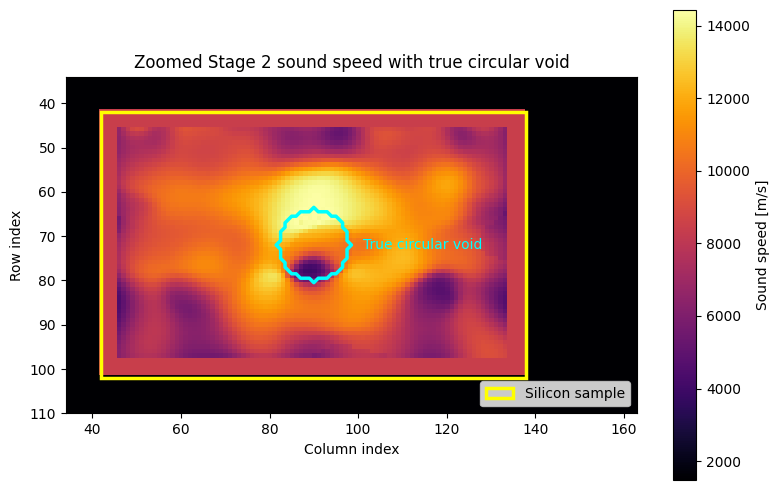

In [1251]:
# ============================================================
# Zoomed Stage 2 sound-speed plot around silicon sample
# ============================================================

plt.figure(figsize=(8, 5))
ax = plt.gca()

margin = 8

im = ax.imshow(
    final_sos,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# Silicon sample boundary
sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)
ax.add_patch(sample_rect)

# True circular void boundary
ax.contour(
    circular_void_mask_for_validation.astype(float),
    levels=[0.5],
    colors="cyan",
    linewidths=2.5
)

ax.text(
    void_center_col + void_radius_cells + 3,
    void_center_row,
    "True circular void",
    color="cyan",
    fontsize=10,
    va="center"
)

ax.set_xlim(sample_left - margin, sample_right + 25)
ax.set_ylim(sample_bottom + margin, sample_top - margin)

ax.set_title("Zoomed Stage 2 sound speed with true circular void")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# End Stage 1 at 20Mhz

# Start of Stage 2 at 85Mhz

In [1252]:
# ============================================================
# MULTISCALE FWI STAGE 2
# Use the final 20 MHz reconstruction as initial model
# Then continue inversion at higher frequency
# ============================================================

# Save final low-frequency result
params_stage1 = get_params(opt_state)

stage1_final_sos = get_sound_speed(params_stage1).on_grid[..., 0]

print("Saved stage 1 parameters.")
print("Stage 1 final min speed:", float(jnp.min(stage1_final_sos)))
print("Stage 1 final max speed:", float(jnp.max(stage1_final_sos)))

Saved stage 1 parameters.
Stage 1 final min speed: 1480.0
Stage 1 final max speed: 14433.197265625


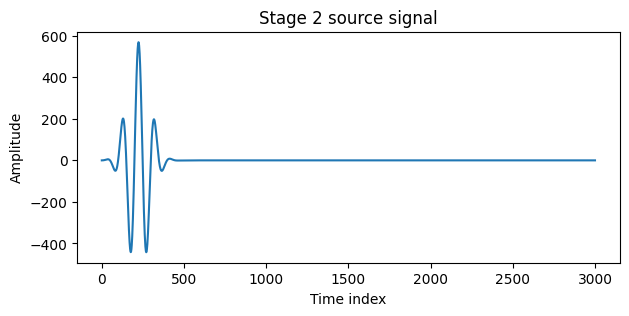

Stage 2 scale factor: 85
Stage 2 source frequency: 85000000.0


In [1253]:
# ============================================================
# Define high-frequency source for stage 2
# ============================================================

scale_factor_stage2 = 85

source_freq = 1e6 * scale_factor_stage2

s1 = source_mag * jnp.sin(
    2 * jnp.pi * source_freq * t
)

# Keep same pulse center
center_index = 200
center_time = center_index * time_axis.dt

# You can keep same sigma first
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)

src_signal = jnp.stack([signal])

plt.figure(figsize=(7, 3))
plt.plot(signal)
plt.title("Stage 2 source signal")
plt.xlabel("Time index")
plt.ylabel("Amplitude")
plt.show()

print("Stage 2 scale factor:", scale_factor_stage2)
print("Stage 2 source frequency:", source_freq)

In [1254]:
# ============================================================
# Redefine forward simulation for stage 2
# This uses the new high-frequency source signal
# ============================================================

@jit
def single_source_simulation(sound_speed, source_num):
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))

    sources = Sources(
        (x, y),
        src_signal,
        dt=time_axis.dt,
        domain=domain
    )

    medium_local = Medium(
        domain=domain,
        sound_speed=sound_speed,
        pml_size=8
    )

    rf_signals = simulate_wave_propagation(
        medium_local,
        time_axis,
        sources=sources,
        sensors=sensors,
    )

    return rf_signals[..., 0]

Stage 2 clean data shape: (40, 3000, 40)


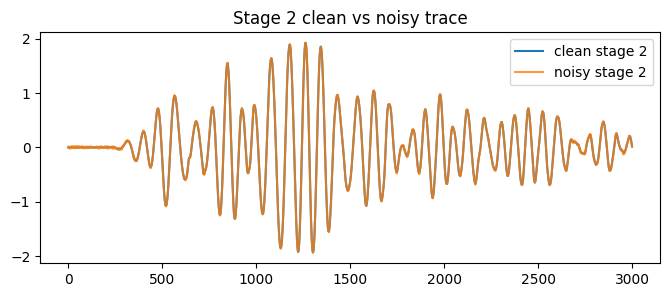

In [1255]:
# ============================================================
# Generate high-frequency observed data for stage 2
# Synthetic case: true data comes from medium.sound_speed
# ============================================================

batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))

p_data_clean_stage2 = batch_simulations(
    medium.sound_speed,
    jnp.arange(num_sources)
)

print("Stage 2 clean data shape:", p_data_clean_stage2.shape)

# Add same relative noise level as before
noise_level = 0.005

p_clean = np.array(p_data_clean_stage2)

trace_scale = np.max(
    np.abs(p_clean),
    axis=1,
    keepdims=True
)

trace_scale[trace_scale == 0] = 1.0

noise = (
    np.random.normal(size=p_clean.shape)
    * noise_level
    * trace_scale
)

p_data = jnp.array(p_clean + noise)

plt.figure(figsize=(8, 3))
plt.plot(p_clean[20, :, 0], label="clean stage 2")
plt.plot(p_data[20, :, 0], label="noisy stage 2", alpha=0.8)
plt.title("Stage 2 clean vs noisy trace")
plt.legend()
plt.show()

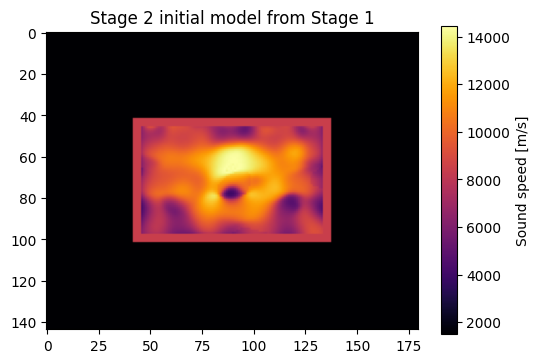

In [1256]:
# ============================================================
# Stage 2 initial model = final Stage 1 model
# ============================================================

params = params_stage1

initial_stage2_sos = get_sound_speed(params).on_grid[..., 0]

plt.figure(figsize=(6, 4))
plt.imshow(initial_stage2_sos, cmap="inferno")
plt.colorbar(label="Sound speed [m/s]")
plt.title("Stage 2 initial model from Stage 1")
plt.show()

In [1257]:
# ============================================================
# Rebuild loss_with_grad for stage 2
# ============================================================

loss_with_grad = value_and_grad(loss_func, argnums=0)

print("Stage 2 using loss function:", loss_name)
print("Stage 2 regularization weight:", regularization_weight)
print("Stage 2 negative update penalty:", use_negative_update_penalty)

Stage 2 using loss function: amplitude_envelope
Stage 2 regularization weight: 1e-05
Stage 2 negative update penalty: False


In [1258]:
# ============================================================
# Stage 2 optimization
# ============================================================

losshistory_stage2 = []
validation_losshistory_stage2 = []
reconstructions_stage2 = []

grad_mean_history_stage2 = []
grad_min_history_stage2 = []
grad_max_history_stage2 = []

num_steps_stage2 = 50
learning_rate_stage2 = 0.01     # safer for high frequency
sources_per_update = 4

init_fun, update_fun, get_params = optimizers.adam(
    learning_rate_stage2,
    0.9,
    0.9
)

opt_state = init_fun(params)


@jit
def update_stage2(opt_state, key, k):
    v = get_params(opt_state)

    src_nums = random.choice(
        key,
        num_sources,
        shape=(sources_per_update,),
        replace=False
    )

    loss_sum = 0.0
    grad_grid_sum = jnp.zeros_like(v.on_grid)

    for i in range(sources_per_update):
        src_num = src_nums[i]

        loss_i, grad_i = loss_with_grad(v, src_num)

        loss_sum = loss_sum + loss_i
        grad_grid_sum = grad_grid_sum + grad_i.on_grid

    lossval = loss_sum / sources_per_update
    gradient_grid = grad_grid_sum / sources_per_update

    gradient = FourierSeries(
        gradient_grid,
        domain
    )

    grad_min = jnp.min(gradient_grid)
    grad_max = jnp.max(gradient_grid)
    grad_mean = jnp.mean(jnp.abs(gradient_grid))

    # Keep gradient smoothing OFF first
    # gradient = smooth_fun(gradient)

    return (
        lossval,
        update_fun(k, gradient, opt_state),
        grad_min,
        grad_max,
        grad_mean
    )


pbar = tqdm(range(num_steps_stage2))

_, key = random.split(random_seed)

for k in pbar:
    _, key = random.split(key)

    lossval, opt_state, grad_min, grad_max, grad_mean = update_stage2(
        opt_state,
        key,
        k
    )

    new_params = get_params(opt_state)

    reconstructions_stage2.append(
        get_sound_speed(new_params).on_grid
    )

    losshistory_stage2.append(float(lossval))

    grad_min_history_stage2.append(float(grad_min))
    grad_max_history_stage2.append(float(grad_max))
    grad_mean_history_stage2.append(float(grad_mean))

    if k % 5 == 0:
        val_loss = validation_loss(new_params)
        validation_losshistory_stage2.append(float(val_loss))
    else:
        validation_losshistory_stage2.append(
            validation_losshistory_stage2[-1]
        )

    pbar.set_description(
        "Stage 2 loss: {:.6f}, Val loss: {:.6f}, Grad mean: {:.3e}".format(
            float(lossval),
            validation_losshistory_stage2[-1],
            float(grad_mean)
        )
    )

Stage 2 loss: 0.048692, Val loss: 0.058553, Grad mean: 1.544e-05: 100%|███| 50/50 [26:37<00:00, 31.95s/it]


In [1259]:
# ============================================================
# SHORT OUTPUT FOLDER NAME FOR CONTRAST-LIMIT STUDY
# ============================================================

void_speed_percent = int(round(100.0 * void_speed_fraction))
void_contrast_percent_int = int(round(100.0 * (1.0 - void_speed_fraction)))
max_update_int = int(round(max_velocity_update))

stage1_frequency_MHz = 20
stage2_frequency_MHz = 85

output_dir = (
    f"fwi_void_"
    f"{stage1_frequency_MHz}to{stage2_frequency_MHz}_"
    f"v{void_speed_percent}_"
    f"c{void_contrast_percent_int}_"
    f"u{max_update_int}"
)

print("Benchmark output folder:", output_dir)

Benchmark output folder: fwi_void_20to85_v10_c90_u7590


In [1260]:
# ============================================================
# FIGURE SAVE SETUP
# Save all figures inside the benchmark output folder
# ============================================================

os.makedirs(output_dir, exist_ok=True)

fig_dir = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

print("Figures will be saved in:")
print(fig_dir)


def save_current_figure(figure_name, dpi=300):
    """
    Save current matplotlib figure inside the benchmark figures folder.
    The filename is short and safe.
    """

    safe_name = (
        figure_name
        .lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("→", "to")
        .replace("/", "_")
        .replace("\\", "_")
    )

    filename = f"{safe_name}.png"
    save_path = os.path.join(fig_dir, filename)

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    print("Saved figure:")
    print(save_path)

    return save_path

Figures will be saved in:
fwi_void_20to85_v10_c90_u7590/figures


In [1261]:
# ============================================================
# SAVE BENCHMARK METADATA FOR CONTRAST-LIMIT STUDY
# ============================================================

benchmark_metadata_df = pd.DataFrame([{
    "benchmark_type": "void_speed_contrast_limit",

    "stage1_frequency_MHz": stage1_frequency_MHz,
    "stage2_frequency_MHz": stage2_frequency_MHz,

    "silicon_background_speed_m_per_s": si_speed,

    "void_speed_fraction": void_speed_fraction,
    "void_speed_percent_of_silicon": 100.0 * void_speed_fraction,

    "void_contrast_fraction_relative_to_silicon": 1.0 - void_speed_fraction,
    "void_contrast_percent_relative_to_silicon": 100.0 * (1.0 - void_speed_fraction),

    "true_void_speed_m_per_s": si_speed * void_speed_fraction,
    "speed_difference_from_silicon_m_per_s": si_speed * (1.0 - void_speed_fraction),
    "required_update_m_per_s": required_update_for_void,

    "max_velocity_update_m_per_s": max_velocity_update,
    "max_update_percent_of_silicon": 100.0 * max_velocity_update / si_speed,

    "void_radius_cells": void_radius_cells,
    "void_radius_micrometers": void_radius_cells * dx[0] * 1e6,

    "num_sources": num_sources,
    "num_sensors": num_sensors,
    "noise_level": noise_level,

    "loss_name": loss_name,
    "regularization_weight": regularization_weight,

    "stage1_num_steps": num_steps,
    "stage2_num_steps": num_steps_stage2,

    "stage1_learning_rate": learning_rate,
    "stage2_learning_rate": learning_rate_stage2,

    "sources_per_update": sources_per_update,
}])

metadata_csv = os.path.join(
    output_dir,
    "TABLE_benchmark_metadata_contrast_limit.csv"
)

benchmark_metadata_df.to_csv(metadata_csv, index=False)

display(benchmark_metadata_df)

print("Saved benchmark metadata:")
print(metadata_csv)

,benchmark_type,stage1_frequency_MHz,stage2_frequency_MHz,silicon_background_speed_m_per_s,void_speed_fraction,void_speed_percent_of_silicon,void_contrast_fraction_relative_to_silicon,void_contrast_percent_relative_to_silicon,true_void_speed_m_per_s,speed_difference_from_silicon_m_per_s,...,num_sources,num_sensors,noise_level,loss_name,regularization_weight,stage1_num_steps,stage2_num_steps,stage1_learning_rate,stage2_learning_rate,sources_per_update
0,void_speed_contrast_limit,20,85,8433.0,0.1,10.0,0.9,90.0,843.3,7589.7,...,40,40,0.005,amplitude_envelope,0.00001,50,50,0.03,0.01,4


Saved benchmark metadata:
fwi_void_20to85_v10_c90_u7590/TABLE_benchmark_metadata_contrast_limit.csv


Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_training_loss_vs_validation_loss.png


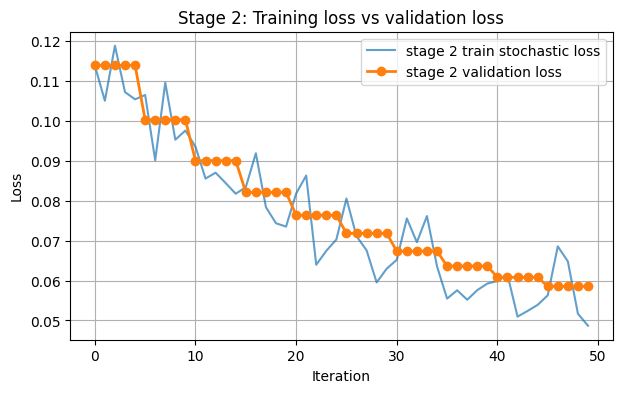

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_gradient_mean_magnitude.png


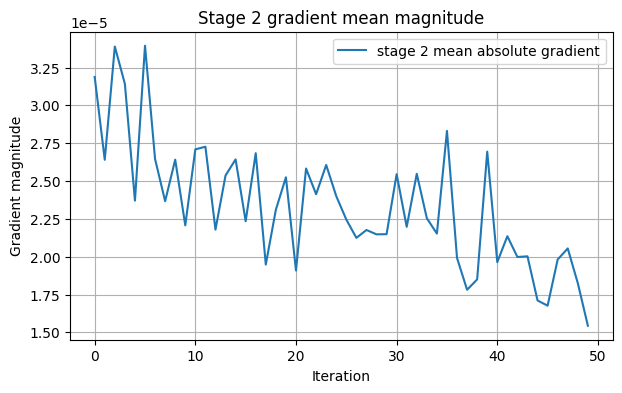

In [1262]:
# ============================================================
# Stage 2 diagnostics
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory_stage2,
    label="stage 2 train stochastic loss",
    alpha=0.7
)

plt.plot(
    validation_losshistory_stage2,
    label="stage 2 validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Stage 2: Training loss vs validation loss")
plt.legend()
plt.grid(True)
save_current_figure("Stage 2: Training loss vs validation loss")
plt.show()


plt.figure(figsize=(7, 4))

plt.plot(
    grad_mean_history_stage2,
    label="stage 2 mean absolute gradient"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient magnitude")
plt.title("Stage 2 gradient mean magnitude")
plt.legend()
plt.grid(True)
save_current_figure("Stage 2 gradient mean magnitude")
plt.show()

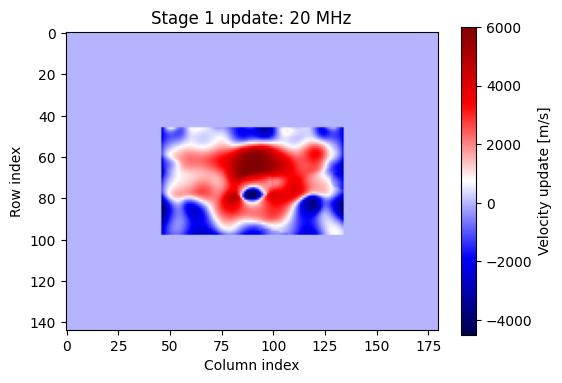

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_total_update_20_mhz_to_85_mhz.png


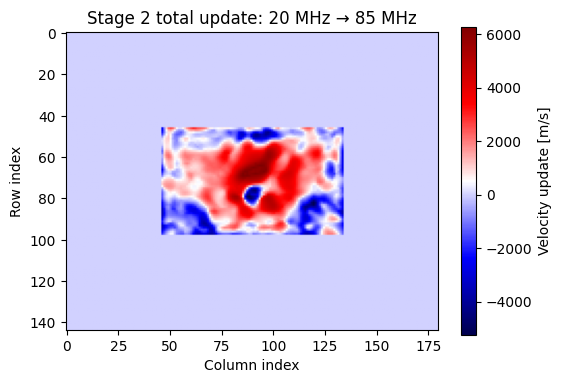

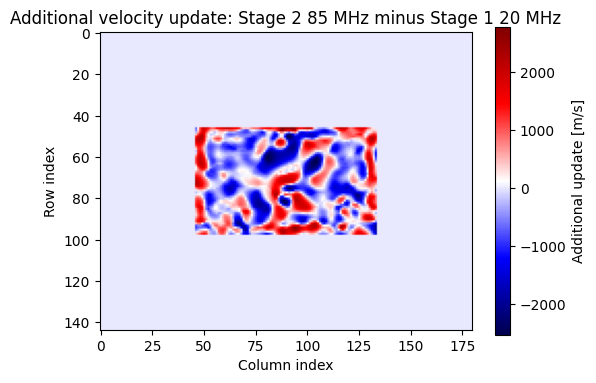

Stage 2 summary
Sources per update: 4
Stage 2 learning rate: 0.01
Stage 2 steps: 50
Stage 2 initial validation loss: 0.1139262467622757
Stage 2 final validation loss: 0.05855301022529602
Stage 2 min total update: -5245.69921875
Stage 2 max total update: 6264.166015625
Stage 2 mean abs total update: 319.21826171875
Stage 2 extra min update: -2530.478515625
Stage 2 extra max update: 2775.44140625
Stage 2 extra mean abs update: 141.13856506347656


In [1263]:
# ============================================================
# Compare Stage 1 and Stage 2 velocity updates
# ============================================================

initial_sos = get_sound_speed(medium.sound_speed * 0.0).on_grid[..., 0]

stage1_sos = get_sound_speed(params_stage1).on_grid[..., 0]
stage2_sos = get_sound_speed(get_params(opt_state)).on_grid[..., 0]

stage1_update = stage1_sos - initial_sos
stage2_update = stage2_sos - initial_sos
stage2_extra_update = stage2_sos - stage1_sos

plt.figure(figsize=(6, 4))
plt.imshow(stage1_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Stage 1 update: 20 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(stage2_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Stage 2 total update: 20 MHz → 85 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
save_current_figure("Stage 2 total update: 20 MHz to 85 MHz")

plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(stage2_extra_update, cmap="seismic")
plt.colorbar(label="Additional update [m/s]")
plt.title("Additional velocity update: Stage 2 85 MHz minus Stage 1 20 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

print("Stage 2 summary")
print("Sources per update:", sources_per_update)
print("Stage 2 learning rate:", learning_rate_stage2)
print("Stage 2 steps:", num_steps_stage2)
print("Stage 2 initial validation loss:", validation_losshistory_stage2[0])
print("Stage 2 final validation loss:", validation_losshistory_stage2[-1])
print("Stage 2 min total update:", float(jnp.min(stage2_update)))
print("Stage 2 max total update:", float(jnp.max(stage2_update)))
print("Stage 2 mean abs total update:", float(jnp.mean(jnp.abs(stage2_update))))
print("Stage 2 extra min update:", float(jnp.min(stage2_extra_update)))
print("Stage 2 extra max update:", float(jnp.max(stage2_extra_update)))
print("Stage 2 extra mean abs update:", float(jnp.mean(jnp.abs(stage2_extra_update))))

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_reconstructed_sound_speed_without_boundaries.png


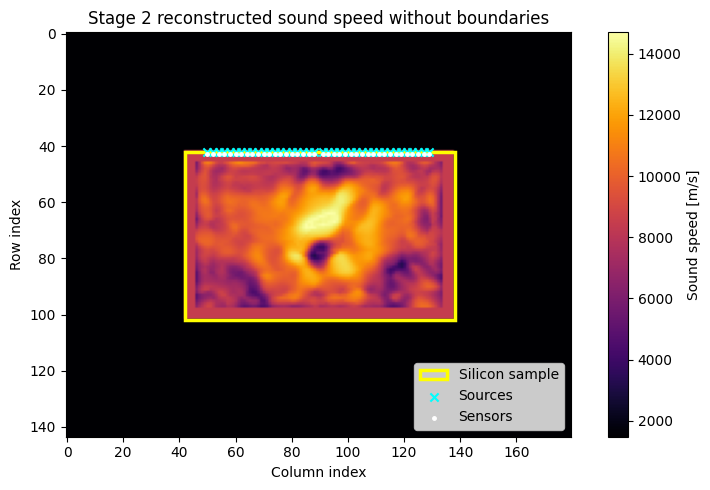

In [1264]:


# ============================================================
# Plot Stage 2 reconstructed sound speed with boundaries
# ============================================================

stage2_sos_np = np.array(stage2_sos)

plt.figure(figsize=(8, 5))
ax = plt.gca()

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# ------------------------------------------------------------
# Silicon sample boundary
# ------------------------------------------------------------

sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)

ax.add_patch(sample_rect)

# ------------------------------------------------------------
# True circular void boundaries
# ------------------------------------------------------------

# ------------------------------------------------------------
# Optional: show sources and sensors
# ------------------------------------------------------------

ax.scatter(
    source_positions[1],
    source_positions[0],
    c="cyan",
    marker="x",
    s=35,
    label="Sources"
)

ax.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="white",
    marker=".",
    s=25,
    label="Sensors"
)

# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------

ax.set_title("Stage 2 reconstructed sound speed without boundaries")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")

ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Stage 2 reconstructed sound speed without boundaries")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_reconstructed_sound_speed_with_true_circular_void_boundary.png


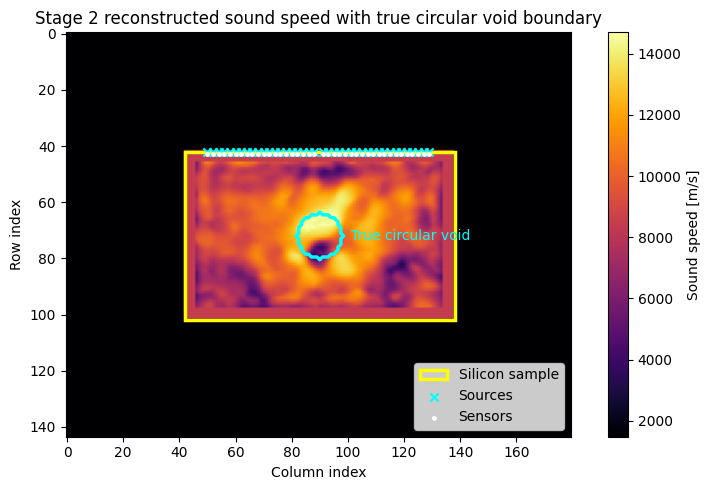

In [1265]:


# ============================================================
# Plot Stage 2 reconstructed sound speed with boundaries
# ============================================================

stage2_sos_np = np.array(stage2_sos)

plt.figure(figsize=(8, 5))
ax = plt.gca()

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# ------------------------------------------------------------
# Silicon sample boundary
# ------------------------------------------------------------

sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)

ax.add_patch(sample_rect)

# True circular void boundary
ax.contour(
    circular_void_mask_for_validation.astype(float),
    levels=[0.5],
    colors="cyan",
    linewidths=2.5
)

ax.text(
    void_center_col + void_radius_cells + 3,
    void_center_row,
    "True circular void",
    color="cyan",
    fontsize=10,
    va="center"
)
# ------------------------------------------------------------
# Optional: show sources and sensors
# ------------------------------------------------------------

ax.scatter(
    source_positions[1],
    source_positions[0],
    c="cyan",
    marker="x",
    s=35,
    label="Sources"
)

ax.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="white",
    marker=".",
    s=25,
    label="Sensors"
)

# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------

ax.set_title("Stage 2 reconstructed sound speed with true circular void boundary")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")

ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Stage 2 reconstructed sound speed with true circular void boundary")

plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/zoomed_stage_2_sound_speed_with_true_circular_void.png


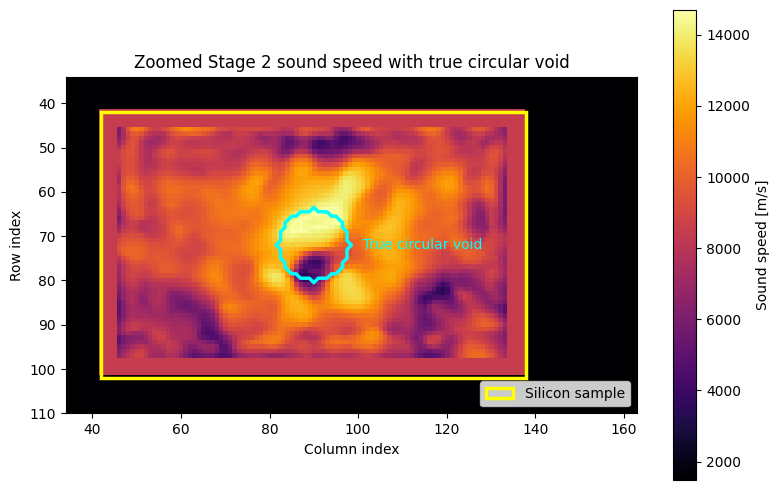

In [1266]:
# ============================================================
# Zoomed Stage 2 sound-speed plot around silicon sample
# ============================================================

plt.figure(figsize=(8, 5))
ax = plt.gca()

margin = 8

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# Silicon sample boundary
sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)
ax.add_patch(sample_rect)

# True circular void boundary
ax.contour(
    circular_void_mask_for_validation.astype(float),
    levels=[0.5],
    colors="cyan",
    linewidths=2.5
)

ax.text(
    void_center_col + void_radius_cells + 3,
    void_center_row,
    "True circular void",
    color="cyan",
    fontsize=10,
    va="center"
)

ax.set_xlim(sample_left - margin, sample_right + 25)
ax.set_ylim(sample_bottom + margin, sample_top - margin)

ax.set_title("Zoomed Stage 2 sound speed with true circular void")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Zoomed Stage 2 sound speed with true circular void")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/stage_2_error_inside_inversion_mask_reconstruction_minus_ground_truth.png


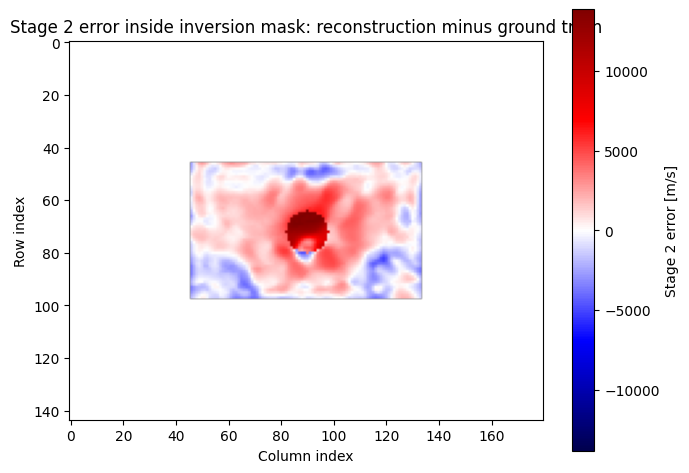

Stage 2 error summary inside inversion mask
Min error [m/s]: -5098.819
Max error [m/s]: 13851.618
Mean signed error [m/s]: 1270.4563
Mean absolute error [m/s]: 2083.1865


In [1267]:
# ============================================================
# Stage 2 error relative to ground truth, only inside inversion mask
# ============================================================

true_sos = medium.sound_speed.on_grid[..., 0]

stage2_error = stage2_sos - true_sos

# Convert to numpy for masking
stage2_error_np = np.array(stage2_error)
inside_inversion_mask_np = np.array(mask_grid).astype(bool)

# Hide everything outside the inversion mask
stage2_error_masked = np.where(
    inside_inversion_mask_np,
    stage2_error_np,
    np.nan
)

absmax_error = np.nanmax(np.abs(stage2_error_masked))

plt.figure(figsize=(7, 5))

plt.imshow(
    stage2_error_masked,
    cmap="seismic",
    vmin=-absmax_error,
    vmax=absmax_error
)

plt.colorbar(label="Stage 2 error [m/s]")
plt.title("Stage 2 error inside inversion mask: reconstruction minus ground truth")
plt.xlabel("Column index")
plt.ylabel("Row index")

plt.tight_layout()
save_current_figure("Stage 2 error inside inversion mask: reconstruction minus ground truth")
plt.show()

print("Stage 2 error summary inside inversion mask")
print("Min error [m/s]:", np.nanmin(stage2_error_masked))
print("Max error [m/s]:", np.nanmax(stage2_error_masked))
print("Mean signed error [m/s]:", np.nanmean(stage2_error_masked))
print("Mean absolute error [m/s]:", np.nanmean(np.abs(stage2_error_masked)))


In [1268]:
# ============================================================
# FINAL SCIENTIFIC CSV ANALYSIS FOR CIRCULAR VOID FWI
# ============================================================
# This replaces the old tectonic-band CSV analysis.
# It evaluates the circular void, not layer_specs or bands.
# ============================================================

os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Convert maps to NumPy arrays
# ------------------------------------------------------------

true_sos_np = np.array(medium.sound_speed.on_grid[..., 0])

initial_sos_np = np.array(
    get_sound_speed(medium.sound_speed * 0.0).on_grid[..., 0]
)

stage1_sos_np = np.array(stage1_sos)
stage2_sos_np = np.array(stage2_sos)

stage1_update_np = stage1_sos_np - initial_sos_np
stage2_update_np = stage2_sos_np - initial_sos_np
stage2_extra_update_np = stage2_sos_np - stage1_sos_np

sample_mask_np = np.array(sample_mask).astype(bool)
mask_grid_np = np.array(mask_grid).astype(bool)

inside_silicon = sample_mask_np
inside_inversion_mask = mask_grid_np

void_mask_np = np.array(circular_void_mask_for_validation).astype(bool)
void_mask_np = void_mask_np & inside_inversion_mask

background_mask_np = (
    inside_silicon
    & inside_inversion_mask
    & (~void_mask_np)
)

true_void_speed = si_speed * void_speed_fraction
true_void_update = true_void_speed - si_speed
required_update_for_void = abs(true_void_update)

print("Full domain shape:", true_sos_np.shape)
print("Silicon pixels inside inversion mask:", np.sum(inside_silicon & inside_inversion_mask))
print("Void pixels inside inversion mask:", np.sum(void_mask_np))
print("Background pixels inside inversion mask:", np.sum(background_mask_np))
print("True void speed [m/s]:", true_void_speed)
print("True void update [m/s]:", true_void_update)
print("Required update magnitude [m/s]:", required_update_for_void)
print("Max velocity update [m/s]:", max_velocity_update)
print("Max update percent of silicon:", 100.0 * max_velocity_update / si_speed)

# ============================================================
# 1. LONG-FORMAT PIXEL MAP
# ============================================================

row_index_z, column_index_x = np.indices(true_sos_np.shape)

z_depth_global_um = row_index_z * dx[0] * 1e6
x_position_global_um = column_index_x * dx[1] * 1e6

z_depth_inside_silicon_um = (row_index_z - sample_top) * dx[0] * 1e6
x_position_inside_silicon_um = (column_index_x - sample_left) * dx[1] * 1e6

z_depth_inside_silicon_um = z_depth_inside_silicon_um.astype(float)
x_position_inside_silicon_um = x_position_inside_silicon_um.astype(float)

z_depth_inside_silicon_um[~inside_silicon] = np.nan
x_position_inside_silicon_um[~inside_silicon] = np.nan

region_label = np.full(true_sos_np.shape, "water_outside_silicon", dtype=object)
region_label[inside_silicon] = "silicon_background"
region_label[void_mask_np] = "circular_void"

true_velocity_contrast_percent = 100.0 * (true_sos_np - si_speed) / si_speed
true_velocity_contrast_percent[~inside_silicon] = np.nan

stage1_error_np = stage1_sos_np - true_sos_np
stage2_error_np = stage2_sos_np - true_sos_np

stage1_abs_error_np = np.abs(stage1_error_np)
stage2_abs_error_np = np.abs(stage2_error_np)

stage2_pixel_error_improvement_np = stage1_abs_error_np - stage2_abs_error_np

map_long_df = pd.DataFrame({
    "row_index_z_depth_direction": row_index_z.ravel(),
    "column_index_x_horizontal_direction": column_index_x.ravel(),

    "z_depth_global_micrometers": z_depth_global_um.ravel(),
    "x_position_global_micrometers": x_position_global_um.ravel(),

    "z_depth_inside_silicon_micrometers": z_depth_inside_silicon_um.ravel(),
    "x_position_inside_silicon_micrometers": x_position_inside_silicon_um.ravel(),

    "inside_silicon_sample": np.where(inside_silicon.ravel(), "yes", "no"),
    "inside_inversion_mask": np.where(inside_inversion_mask.ravel(), "yes", "no"),
    "inside_true_circular_void": np.where(void_mask_np.ravel(), "yes", "no"),

    "region_label": region_label.ravel(),

    "true_sound_speed_m_per_s": true_sos_np.ravel(),
    "true_velocity_contrast_percent_relative_to_silicon": true_velocity_contrast_percent.ravel(),

    "initial_sound_speed_m_per_s": initial_sos_np.ravel(),

    "stage1_sound_speed_m_per_s": stage1_sos_np.ravel(),
    "stage2_sound_speed_m_per_s": stage2_sos_np.ravel(),

    "stage1_velocity_update_relative_to_initial_m_per_s": stage1_update_np.ravel(),
    "stage2_velocity_update_relative_to_initial_m_per_s": stage2_update_np.ravel(),
    "stage2_extra_update_relative_to_stage1_m_per_s": stage2_extra_update_np.ravel(),

    "stage1_error_reconstructed_minus_true_m_per_s": stage1_error_np.ravel(),
    "stage2_error_reconstructed_minus_true_m_per_s": stage2_error_np.ravel(),

    "stage1_absolute_error_m_per_s": stage1_abs_error_np.ravel(),
    "stage2_absolute_error_m_per_s": stage2_abs_error_np.ravel(),

    "stage2_pixel_error_improvement_m_per_s": stage2_pixel_error_improvement_np.ravel(),
})

map_long_csv = os.path.join(
    output_dir,
    "MAP_LONG_FORMAT_all_pixels_with_void_labels_and_errors.csv"
)

map_long_df.to_csv(map_long_csv, index=False)

display(map_long_df.head(20))

print("Saved long-format circular void map CSV:")
print(map_long_csv)

# ============================================================
# 2. GLOBAL RECONSTRUCTION METRICS
# ============================================================

eval_mask = inside_inversion_mask

true_eval = true_sos_np[eval_mask]
stage1_eval = stage1_sos_np[eval_mask]
stage2_eval = stage2_sos_np[eval_mask]


def compute_global_metrics_for_stage(reconstructed, true, stage_name, stage_description):
    error = reconstructed - true

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)

    true_range = np.max(true) - np.min(true)

    if true_range > 0:
        nrmse_percent = 100.0 * rmse / true_range
    else:
        nrmse_percent = np.nan

    if np.std(reconstructed) > 0 and np.std(true) > 0:
        correlation = np.corrcoef(reconstructed.ravel(), true.ravel())[0, 1]
    else:
        correlation = np.nan

    return [
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "MAE",
            "Metric full name": "Mean Absolute Error",
            "Value": mae,
            "Unit": "m/s",
            "Formula used": "mean(abs(reconstructed_speed - true_speed))",
            "Meaning": "Average absolute velocity error inside the inversion mask.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "RMSE",
            "Metric full name": "Root Mean Squared Error",
            "Value": rmse,
            "Unit": "m/s",
            "Formula used": "sqrt(mean((reconstructed_speed - true_speed)^2))",
            "Meaning": "Typical velocity error, with large errors penalized more strongly.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "Bias",
            "Metric full name": "Mean Signed Error",
            "Value": bias,
            "Unit": "m/s",
            "Formula used": "mean(reconstructed_speed - true_speed)",
            "Meaning": "Average signed error. Positive means too fast; negative means too slow.",
            "Good result": "Closer to zero is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "NRMSE",
            "Metric full name": "Normalized Root Mean Squared Error",
            "Value": nrmse_percent,
            "Unit": "%",
            "Formula used": "100 * RMSE / (max(true_speed) - min(true_speed))",
            "Meaning": "RMSE expressed as percent of the true velocity range.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "Correlation",
            "Metric full name": "Pearson Spatial Correlation",
            "Value": correlation,
            "Unit": "unitless",
            "Formula used": "corrcoef(reconstructed_speed_flat, true_speed_flat)",
            "Meaning": "Spatial similarity between reconstructed and true velocity maps.",
            "Good result": "Closer to 1 is better."
        },
    ]


global_rows = []

global_rows.extend(
    compute_global_metrics_for_stage(
        stage1_eval,
        true_eval,
        "Stage 1",
        "20 MHz low-frequency FWI reconstruction"
    )
)

global_rows.extend(
    compute_global_metrics_for_stage(
        stage2_eval,
        true_eval,
        "Stage 2",
        "85 MHz high-frequency FWI reconstruction initialized from Stage 1"
    )
)

global_metrics_readable_df = pd.DataFrame(global_rows)

global_metrics_readable_df.insert(0, "benchmark_num_bands", 0)
global_metrics_readable_df.insert(1, "void_speed_fraction", void_speed_fraction)
global_metrics_readable_df.insert(2, "max_velocity_update_m_per_s", max_velocity_update)

global_metrics_csv = os.path.join(
    output_dir,
    "TABLE_global_reconstruction_metrics_READABLE.csv"
)

global_metrics_readable_df.to_csv(global_metrics_csv, index=False)

display(global_metrics_readable_df)

print("Saved global metrics CSV:")
print(global_metrics_csv)

# ============================================================
# 3. CIRCULAR VOID SCIENTIFIC METRICS
# ============================================================

def compute_void_metrics(stage_name, stage_description, sos_map, update_map):
    reconstructed_void_values = sos_map[void_mask_np]
    true_void_values = true_sos_np[void_mask_np]

    reconstructed_background_values = sos_map[background_mask_np]
    true_background_values = true_sos_np[background_mask_np]

    void_error = reconstructed_void_values - true_void_values
    background_error = reconstructed_background_values - true_background_values

    reconstructed_mean_void_speed = np.mean(reconstructed_void_values)
    reconstructed_median_void_speed = np.median(reconstructed_void_values)
    reconstructed_std_void_speed = np.std(reconstructed_void_values)

    reconstructed_mean_void_update = np.mean(update_map[void_mask_np])

    void_mae = np.mean(np.abs(void_error))
    void_rmse = np.sqrt(np.mean(void_error ** 2))
    void_bias = np.mean(void_error)

    background_mae = np.mean(np.abs(background_error))
    background_rmse = np.sqrt(np.mean(background_error ** 2))
    background_bias = np.mean(background_error)

    if abs(true_void_update) > 0:
        void_update_recovery_percent = (
            100.0 * reconstructed_mean_void_update / true_void_update
        )
    else:
        void_update_recovery_percent = np.nan

    theoretical_max_recovery_percent = min(
        100.0,
        100.0 * max_velocity_update / required_update_for_void
    )

    # The circular void is a slow defect, so useful signal is negative update.
    useful_void_signal = np.maximum(-update_map, 0.0)

    void_energy = np.mean(useful_void_signal[void_mask_np])
    background_energy = np.mean(useful_void_signal[background_mask_np])

    if void_energy + background_energy > 0:
        void_detection_efficiency = void_energy / (
            void_energy + background_energy
        )
    else:
        void_detection_efficiency = np.nan

    if void_energy > 0:
        false_positive_ratio = background_energy / void_energy
    else:
        false_positive_ratio = np.nan

    wrong_sign_energy_inside_void = np.mean(
        np.maximum(update_map[void_mask_np], 0.0)
    )

    if void_energy > 0:
        wrong_sign_ratio_inside_void = wrong_sign_energy_inside_void / void_energy
    else:
        wrong_sign_ratio_inside_void = np.nan



    # ------------------------------------------------------------
    # Scientific pass/fail criteria for contrast-limit study
    # ------------------------------------------------------------    
    recovery_ok = (
        (void_update_recovery_percent >= 70.0)
        and (void_update_recovery_percent <= 130.0)
    )
    
    localization_ok = void_detection_efficiency >= 0.60
    false_positive_ok = false_positive_ratio <= 0.50
    wrong_sign_ok = wrong_sign_ratio_inside_void <= 0.30
    background_ok = background_mae <= 0.25 * required_update_for_void

    successful_detection = (
        recovery_ok
        and localization_ok
        and false_positive_ok
        and wrong_sign_ok
        and background_ok
    )  

    return {
        "FWI stage": stage_name,
        "Stage description": stage_description,

        "void_speed_fraction": void_speed_fraction,
        "void_speed_percent_of_silicon": 100.0 * void_speed_fraction,
        
        "void_contrast_fraction_relative_to_silicon": 1.0 - void_speed_fraction,
        "void_contrast_percent_relative_to_silicon": 100.0 * (1.0 - void_speed_fraction),
        
        "true_void_speed_m_per_s": true_void_speed,
        "silicon_background_speed_m_per_s": si_speed,
        
        "speed_difference_from_silicon_m_per_s": si_speed - true_void_speed,
        "speed_difference_percent_of_silicon": 100.0 * (si_speed - true_void_speed) / si_speed,
        
        "true_void_update_relative_to_silicon_m_per_s": true_void_update,
        "required_update_m_per_s": required_update_for_void,

        "max_velocity_update_m_per_s": max_velocity_update,
        "max_update_percent_of_silicon": 100.0 * max_velocity_update / si_speed,
        "theoretical_max_recovery_percent_due_to_range": theoretical_max_recovery_percent,

        "reconstructed_mean_void_speed_m_per_s": reconstructed_mean_void_speed,
        "reconstructed_median_void_speed_m_per_s": reconstructed_median_void_speed,
        "reconstructed_std_void_speed_m_per_s": reconstructed_std_void_speed,
        "reconstructed_mean_void_update_m_per_s": reconstructed_mean_void_update,

        "void_velocity_update_recovery_percent": void_update_recovery_percent,

        "void_MAE_m_per_s": void_mae,
        "void_RMSE_m_per_s": void_rmse,
        "void_Bias_m_per_s": void_bias,

        "background_MAE_m_per_s": background_mae,
        "background_RMSE_m_per_s": background_rmse,
        "background_Bias_m_per_s": background_bias,

        "void_expected_negative_energy_m_per_s": void_energy,
        "background_false_negative_energy_m_per_s": background_energy,
        "void_detection_efficiency_0_to_1": void_detection_efficiency,
        "false_positive_ratio_background_to_void": false_positive_ratio,

        "wrong_sign_positive_energy_inside_void_m_per_s": wrong_sign_energy_inside_void,
        "wrong_sign_ratio_inside_void": wrong_sign_ratio_inside_void,

        "recovery_ok": recovery_ok,
        "localization_ok": localization_ok,
        "false_positive_ok": false_positive_ok,
        "wrong_sign_ok": wrong_sign_ok,
        "background_ok": background_ok,
        "successful_detection": successful_detection,

        "number_of_void_pixels": int(np.sum(void_mask_np)),
        "number_of_background_pixels": int(np.sum(background_mask_np)),
    }


void_metrics_readable_df = pd.DataFrame([
    compute_void_metrics(
        "Stage 1",
        "20 MHz low-frequency FWI reconstruction",
        stage1_sos_np,
        stage1_update_np,
    ),
    compute_void_metrics(
        "Stage 2",
        "85 MHz high-frequency FWI reconstruction initialized from Stage 1",
        stage2_sos_np,
        stage2_update_np,
    ),
])

void_metrics_csv = os.path.join(
    output_dir,
    "TABLE_circular_void_scientific_metrics_READABLE.csv"
)

void_metrics_readable_df.to_csv(void_metrics_csv, index=False)

display(void_metrics_readable_df)

print("Saved circular void metrics CSV:")
print(void_metrics_csv)

# ============================================================
# 4. STAGE 1 VS STAGE 2 VOID IMPROVEMENT
# ============================================================

stage1_row = void_metrics_readable_df[
    void_metrics_readable_df["FWI stage"] == "Stage 1"
].iloc[0]

stage2_row = void_metrics_readable_df[
    void_metrics_readable_df["FWI stage"] == "Stage 2"
].iloc[0]

void_improvement_df = pd.DataFrame([{
    "defect_type": "circular_void",

    "Stage 1 void MAE m/s": stage1_row["void_MAE_m_per_s"],
    "Stage 2 void MAE m/s": stage2_row["void_MAE_m_per_s"],
    "Void MAE improvement m/s": stage1_row["void_MAE_m_per_s"] - stage2_row["void_MAE_m_per_s"],
    "Void MAE improved yes/no": "yes" if stage2_row["void_MAE_m_per_s"] < stage1_row["void_MAE_m_per_s"] else "no",

    "Stage 1 void RMSE m/s": stage1_row["void_RMSE_m_per_s"],
    "Stage 2 void RMSE m/s": stage2_row["void_RMSE_m_per_s"],
    "Void RMSE improvement m/s": stage1_row["void_RMSE_m_per_s"] - stage2_row["void_RMSE_m_per_s"],
    "Void RMSE improved yes/no": "yes" if stage2_row["void_RMSE_m_per_s"] < stage1_row["void_RMSE_m_per_s"] else "no",

    "Stage 1 recovery percent": stage1_row["void_velocity_update_recovery_percent"],
    "Stage 2 recovery percent": stage2_row["void_velocity_update_recovery_percent"],
    "Recovery percent improvement": stage2_row["void_velocity_update_recovery_percent"] - stage1_row["void_velocity_update_recovery_percent"],

    "Stage 1 detection efficiency": stage1_row["void_detection_efficiency_0_to_1"],
    "Stage 2 detection efficiency": stage2_row["void_detection_efficiency_0_to_1"],
    "Detection efficiency improvement": stage2_row["void_detection_efficiency_0_to_1"] - stage1_row["void_detection_efficiency_0_to_1"],

    "Stage 1 false positive ratio": stage1_row["false_positive_ratio_background_to_void"],
    "Stage 2 false positive ratio": stage2_row["false_positive_ratio_background_to_void"],
    "False positive reduction": stage1_row["false_positive_ratio_background_to_void"] - stage2_row["false_positive_ratio_background_to_void"],

    "Stage 1 background MAE m/s": stage1_row["background_MAE_m_per_s"],
    "Stage 2 background MAE m/s": stage2_row["background_MAE_m_per_s"],
    "Background MAE improvement m/s": stage1_row["background_MAE_m_per_s"] - stage2_row["background_MAE_m_per_s"],

    "Stage 1 successful detection": stage1_row["successful_detection"],
    "Stage 2 successful detection": stage2_row["successful_detection"],
}])

void_improvement_csv = os.path.join(
    output_dir,
    "TABLE_stage1_vs_stage2_circular_void_improvement_READABLE.csv"
)

void_improvement_df.to_csv(void_improvement_csv, index=False)

display(void_improvement_df)

print("Saved circular void improvement CSV:")
print(void_improvement_csv)

# ============================================================
# 5. CIRCULAR VOID METRIC DICTIONARY
# ============================================================

metric_dictionary_rows = [
    {
        "Metric name": "Void velocity update recovery percent",
        "Formula": "100 * reconstructed_mean_void_update / true_void_update",
        "Unit": "%",
        "Meaning": "How much of the true slow-void velocity update was recovered.",
        "Good result": "Close to 100% is ideal."
    },
    {
        "Metric name": "Void detection efficiency",
        "Formula": "void_expected_negative_energy / (void_expected_negative_energy + background_expected_negative_energy)",
        "Unit": "0 to 1",
        "Meaning": "How concentrated the slow-update signal is inside the true circular void.",
        "Good result": "Closer to 1 is better."
    },
    {
        "Metric name": "False positive ratio",
        "Formula": "background_expected_negative_energy / void_expected_negative_energy",
        "Unit": "unitless",
        "Meaning": "Slow-defect artifact strength outside the void relative to inside the void.",
        "Good result": "Closer to 0 is better."
    },
    {
        "Metric name": "Wrong-sign ratio inside void",
        "Formula": "positive_update_energy_inside_void / negative_update_energy_inside_void",
        "Unit": "unitless",
        "Meaning": "Whether the inversion creates fast artifacts inside a true slow void.",
        "Good result": "Closer to 0 is better."
    },
    {
        "Metric name": "Background MAE",
        "Formula": "mean(abs(reconstructed_background_speed - true_background_speed))",
        "Unit": "m/s",
        "Meaning": "Velocity error outside the void but inside the silicon inversion mask.",
        "Good result": "Lower is better."
    },
]

metric_dictionary_df = pd.DataFrame(metric_dictionary_rows)

metric_dictionary_csv = os.path.join(
    output_dir,
    "TABLE_circular_void_metric_dictionary_READABLE.csv"
)

metric_dictionary_df.to_csv(metric_dictionary_csv, index=False)

display(metric_dictionary_df)

print("Saved circular void metric dictionary CSV:")
print(metric_dictionary_csv)

# ============================================================
# 6. PLAIN-LANGUAGE CONCLUSIONS
# ============================================================

conclusion_rows = []

stage1_global_mae = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 1")
    & (global_metrics_readable_df["Metric short name"] == "MAE")
]["Value"].iloc[0]

stage2_global_mae = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 2")
    & (global_metrics_readable_df["Metric short name"] == "MAE")
]["Value"].iloc[0]

conclusion_rows.append({
    "Category": "Global reconstruction",
    "Conclusion": (
        "Stage 2 improved the global MAE."
        if stage2_global_mae < stage1_global_mae
        else "Stage 2 did not improve the global MAE."
    ),
    "Evidence": f"Global MAE changed from {stage1_global_mae:.2f} m/s to {stage2_global_mae:.2f} m/s."
})

conclusion_rows.append({
    "Category": "Void amplitude recovery",
    "Conclusion": (
        "Stage 2 improved the recovered void amplitude."
        if stage2_row["void_velocity_update_recovery_percent"] > stage1_row["void_velocity_update_recovery_percent"]
        else "Stage 2 did not improve the recovered void amplitude."
    ),
    "Evidence": (
        f"Void recovery changed from "
        f"{stage1_row['void_velocity_update_recovery_percent']:.2f}% to "
        f"{stage2_row['void_velocity_update_recovery_percent']:.2f}%."
    )
})

conclusion_rows.append({
    "Category": "Void localization",
    "Conclusion": (
        "Stage 2 improved void localization."
        if stage2_row["void_detection_efficiency_0_to_1"] > stage1_row["void_detection_efficiency_0_to_1"]
        else "Stage 2 did not improve void localization."
    ),
    "Evidence": (
        f"Detection efficiency changed from "
        f"{stage1_row['void_detection_efficiency_0_to_1']:.3f} to "
        f"{stage2_row['void_detection_efficiency_0_to_1']:.3f}."
    )
})

conclusion_rows.append({
    "Category": "Stage 2 detection decision",
    "Conclusion": (
        "Stage 2 passed the circular void detection criteria."
        if bool(stage2_row["successful_detection"])
        else "Stage 2 did not pass the circular void detection criteria."
    ),
    "Evidence": (
        f"Recovery OK: {stage2_row['recovery_ok']}, "
        f"localization OK: {stage2_row['localization_ok']}, "
        f"false positive OK: {stage2_row['false_positive_ok']}, "
        f"background OK: {stage2_row['background_ok']}."
    )
})

conclusion_df = pd.DataFrame(conclusion_rows)

conclusion_csv = os.path.join(
    output_dir,
    "TABLE_circular_void_plain_language_conclusions_READABLE.csv"
)

conclusion_df.to_csv(conclusion_csv, index=False)

display(conclusion_df)

print("Saved circular void conclusions CSV:")
print(conclusion_csv)

print("\nDONE.")
print("Circular void scientific results saved in folder:")
print(output_dir)

Full domain shape: (144, 180)
Silicon pixels inside inversion mask: 4576
Void pixels inside inversion mask: 197
Background pixels inside inversion mask: 4379
True void speed [m/s]: 843.3000000000001
True void update [m/s]: -7589.7
Required update magnitude [m/s]: 7589.7
Max velocity update [m/s]: 7589.7
Max update percent of silicon: 90.0


,row_index_z_depth_direction,column_index_x_horizontal_direction,z_depth_global_micrometers,x_position_global_micrometers,z_depth_inside_silicon_micrometers,x_position_inside_silicon_micrometers,inside_silicon_sample,inside_inversion_mask,inside_true_circular_void,region_label,...,stage1_sound_speed_m_per_s,stage2_sound_speed_m_per_s,stage1_velocity_update_relative_to_initial_m_per_s,stage2_velocity_update_relative_to_initial_m_per_s,stage2_extra_update_relative_to_stage1_m_per_s,stage1_error_reconstructed_minus_true_m_per_s,stage2_error_reconstructed_minus_true_m_per_s,stage1_absolute_error_m_per_s,stage2_absolute_error_m_per_s,stage2_pixel_error_improvement_m_per_s
0,0,0,0.0,0.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,0.0,5.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,2,0.0,10.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,0.0,15.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,4,0.0,20.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,5,0.0,25.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,6,0.0,30.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,7,0.0,35.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,8,0.0,40.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,9,0.0,45.0,NaN,NaN,no,no,no,water_outside_silicon,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved long-format circular void map CSV:
fwi_void_20to85_v10_c90_u7590/MAP_LONG_FORMAT_all_pixels_with_void_labels_and_errors.csv


,benchmark_num_bands,void_speed_fraction,max_velocity_update_m_per_s,FWI stage,Stage description,Metric short name,Metric full name,Value,Unit,Formula used,Meaning,Good result
0,0,0.1,7589.7,Stage 1,20 MHz low-frequency FWI reconstruction,MAE,Mean Absolute Error,2192.825928,m/s,mean(abs(reconstructed_speed - true_speed)),Average absolute velocity error inside the inv...,Lower is better.
1,0,0.1,7589.7,Stage 1,20 MHz low-frequency FWI reconstruction,RMSE,Root Mean Squared Error,3085.933838,m/s,sqrt(mean((reconstructed_speed - true_speed)^2)),"Typical velocity error, with large errors pena...",Lower is better.
2,0,0.1,7589.7,Stage 1,20 MHz low-frequency FWI reconstruction,Bias,Mean Signed Error,1291.791992,m/s,mean(reconstructed_speed - true_speed),Average signed error. Positive means too fast;...,Closer to zero is better.
3,0,0.1,7589.7,Stage 1,20 MHz low-frequency FWI reconstruction,NRMSE,Normalized Root Mean Squared Error,40.659496,%,100 * RMSE / (max(true_speed) - min(true_speed)),RMSE expressed as percent of the true velocity...,Lower is better.
4,0,0.1,7589.7,Stage 1,20 MHz low-frequency FWI reconstruction,Correlation,Pearson Spatial Correlation,-0.127139,unitless,"corrcoef(reconstructed_speed_flat, true_speed_...",Spatial similarity between reconstructed and t...,Closer to 1 is better.
5,0,0.1,7589.7,Stage 2,85 MHz high-frequency FWI reconstruction initi...,MAE,Mean Absolute Error,2083.186523,m/s,mean(abs(reconstructed_speed - true_speed)),Average absolute velocity error inside the inv...,Lower is better.
6,0,0.1,7589.7,Stage 2,85 MHz high-frequency FWI reconstruction initi...,RMSE,Root Mean Squared Error,3077.026855,m/s,sqrt(mean((reconstructed_speed - true_speed)^2)),"Typical velocity error, with large errors pena...",Lower is better.
7,0,0.1,7589.7,Stage 2,85 MHz high-frequency FWI reconstruction initi...,Bias,Mean Signed Error,1270.456299,m/s,mean(reconstructed_speed - true_speed),Average signed error. Positive means too fast;...,Closer to zero is better.
8,0,0.1,7589.7,Stage 2,85 MHz high-frequency FWI reconstruction initi...,NRMSE,Normalized Root Mean Squared Error,40.542141,%,100 * RMSE / (max(true_speed) - min(true_speed)),RMSE expressed as percent of the true velocity...,Lower is better.
9,0,0.1,7589.7,Stage 2,85 MHz high-frequency FWI reconstruction initi...,Correlation,Pearson Spatial Correlation,-0.188460,unitless,"corrcoef(reconstructed_speed_flat, true_speed_...",Spatial similarity between reconstructed and t...,Closer to 1 is better.


Saved global metrics CSV:
fwi_void_20to85_v10_c90_u7590/TABLE_global_reconstruction_metrics_READABLE.csv


...

Saved circular void improvement CSV:
fwi_void_20to85_v10_c90_u7590/TABLE_stage1_vs_stage2_circular_void_improvement_READABLE.csv


,Metric name,Formula,Unit,Meaning,Good result
0,Void velocity update recovery percent,100 * reconstructed_mean_void_update / true_vo...,%,How much of the true slow-void velocity update...,Close to 100% is ideal.
1,Void detection efficiency,void_expected_negative_energy / (void_expected...,0 to 1,How concentrated the slow-update signal is ins...,Closer to 1 is better.
2,False positive ratio,background_expected_negative_energy / void_exp...,unitless,Slow-defect artifact strength outside the void...,Closer to 0 is better.
3,Wrong-sign ratio inside void,positive_update_energy_inside_void / negative_...,unitless,Whether the inversion creates fast artifacts i...,Closer to 0 is better.
4,Background MAE,mean(abs(reconstructed_background_speed - true...,m/s,Velocity error outside the void but inside the...,Lower is better.


Saved circular void metric dictionary CSV:
fwi_void_20to85_v10_c90_u7590/TABLE_circular_void_metric_dictionary_READABLE.csv


,Category,Conclusion,Evidence
0,Global reconstruction,Stage 2 improved the global MAE.,Global MAE changed from 2192.83 m/s to 2083.19...
1,Void amplitude recovery,Stage 2 did not improve the recovered void amp...,Void recovery changed from -29.72% to -36.65%.
2,Void localization,Stage 2 improved void localization.,Detection efficiency changed from 0.544 to 0.586.
3,Stage 2 detection decision,Stage 2 did not pass the circular void detecti...,"Recovery OK: False, localization OK: False, fa..."


Saved circular void conclusions CSV:
fwi_void_20to85_v10_c90_u7590/TABLE_circular_void_plain_language_conclusions_READABLE.csv

DONE.
Circular void scientific results saved in folder:
fwi_void_20to85_v10_c90_u7590


In [1269]:
# ============================================================
# CIRCULAR VOID SHAPE / BOUNDARY DEVIATION ANALYSIS
# ============================================================
# This replaces tectonic-band boundary deviation.
# It checks whether the detected slow anomaly overlaps the true void.
# ============================================================

os.makedirs(output_dir, exist_ok=True)

true_void_mask = void_mask_np.copy()

true_void_area_pixels = np.sum(true_void_mask)

true_void_center_row = void_center_row
true_void_center_col = void_center_col
true_void_radius_cells = void_radius_cells

true_void_area_equivalent_radius_cells = np.sqrt(true_void_area_pixels / np.pi)

# A detected void pixel is a pixel with negative update at least
# this fraction of the true required update.
detection_threshold_fraction = 0.50

detection_threshold_m_per_s = (
    detection_threshold_fraction * required_update_for_void
)

print("Void detection threshold [m/s]:", detection_threshold_m_per_s)


def compute_detected_void_shape_metrics(stage_name, stage_description, update_map):
    slow_update_strength = np.maximum(-update_map, 0.0)

    detected_void_mask = (
        slow_update_strength >= detection_threshold_m_per_s
    ) & inside_inversion_mask

    detected_area_pixels = np.sum(detected_void_mask)

    intersection = detected_void_mask & true_void_mask
    union = detected_void_mask | true_void_mask

    intersection_pixels = np.sum(intersection)
    union_pixels = np.sum(union)

    if union_pixels > 0:
        iou = intersection_pixels / union_pixels
    else:
        iou = np.nan

    if true_void_area_pixels > 0:
        recall = intersection_pixels / true_void_area_pixels
    else:
        recall = np.nan

    if detected_area_pixels > 0:
        precision = intersection_pixels / detected_area_pixels
    else:
        precision = np.nan

    if precision + recall > 0:
        f1_score = 2.0 * precision * recall / (precision + recall)
    else:
        f1_score = np.nan

    if detected_area_pixels > 0:
        detected_rows, detected_cols = np.where(detected_void_mask)

        detected_center_row = np.mean(detected_rows)
        detected_center_col = np.mean(detected_cols)

        detected_equivalent_radius_cells = np.sqrt(detected_area_pixels / np.pi)

        center_error_cells = np.sqrt(
            (detected_center_row - true_void_center_row) ** 2
            + (detected_center_col - true_void_center_col) ** 2
        )

        center_error_um = center_error_cells * dx[0] * 1e6

        radius_error_cells = (
            detected_equivalent_radius_cells
            - true_void_area_equivalent_radius_cells
        )

        radius_error_um = radius_error_cells * dx[0] * 1e6

        detected_area_um2 = detected_area_pixels * dx[0] * dx[1] * 1e12
    else:
        detected_center_row = np.nan
        detected_center_col = np.nan
        detected_equivalent_radius_cells = np.nan
        center_error_cells = np.nan
        center_error_um = np.nan
        radius_error_cells = np.nan
        radius_error_um = np.nan
        detected_area_um2 = np.nan

    true_area_um2 = true_void_area_pixels * dx[0] * dx[1] * 1e12

    return {
        "FWI stage": stage_name,
        "Stage description": stage_description,

        "detection_threshold_fraction_of_true_update": detection_threshold_fraction,
        "detection_threshold_m_per_s": detection_threshold_m_per_s,

        "true_void_center_row": true_void_center_row,
        "true_void_center_col": true_void_center_col,
        "true_void_radius_cells": true_void_radius_cells,
        "true_void_area_pixels": int(true_void_area_pixels),
        "true_void_area_square_micrometers": true_area_um2,

        "detected_void_area_pixels": int(detected_area_pixels),
        "detected_void_area_square_micrometers": detected_area_um2,

        "detected_center_row": detected_center_row,
        "detected_center_col": detected_center_col,

        "center_error_cells": center_error_cells,
        "center_error_micrometers": center_error_um,

        "true_equivalent_radius_cells": true_void_area_equivalent_radius_cells,
        "detected_equivalent_radius_cells": detected_equivalent_radius_cells,
        "radius_error_cells": radius_error_cells,
        "radius_error_micrometers": radius_error_um,

        "intersection_pixels": int(intersection_pixels),
        "union_pixels": int(union_pixels),

        "IoU_intersection_over_union": iou,
        "precision_detected_pixels_inside_true_void": precision,
        "recall_true_void_pixels_detected": recall,
        "F1_score": f1_score,
    }


void_shape_boundary_df = pd.DataFrame([
    compute_detected_void_shape_metrics(
        "Stage 1",
        "20 MHz low-frequency FWI reconstruction",
        stage1_update_np,
    ),
    compute_detected_void_shape_metrics(
        "Stage 2",
        "85 MHz high-frequency FWI reconstruction initialized from Stage 1",
        stage2_update_np,
    ),
])

void_shape_boundary_csv = os.path.join(
    output_dir,
    "TABLE_circular_void_shape_boundary_deviation_READABLE.csv"
)

void_shape_boundary_df.to_csv(void_shape_boundary_csv, index=False)

display(void_shape_boundary_df)

print("Saved circular void shape / boundary deviation CSV:")
print(void_shape_boundary_csv)

Void detection threshold [m/s]: 3794.85


,FWI stage,Stage description,detection_threshold_fraction_of_true_update,detection_threshold_m_per_s,true_void_center_row,true_void_center_col,true_void_radius_cells,true_void_area_pixels,true_void_area_square_micrometers,detected_void_area_pixels,...,true_equivalent_radius_cells,detected_equivalent_radius_cells,radius_error_cells,radius_error_micrometers,intersection_pixels,union_pixels,IoU_intersection_over_union,precision_detected_pixels_inside_true_void,recall_true_void_pixels_detected,F1_score
0,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,3794.85,72,90,8,197,4925.0,19,...,7.918778,2.459245,-5.459533,-27.297664,12,204,0.058824,0.631579,0.060914,0.111111
1,Stage 2,85 MHz high-frequency FWI reconstruction initi...,0.5,3794.85,72,90,8,197,4925.0,44,...,7.918778,3.742410,-4.176368,-20.881839,14,227,0.061674,0.318182,0.071066,0.116183


Saved circular void shape / boundary deviation CSV:
fwi_void_20to85_v10_c90_u7590/TABLE_circular_void_shape_boundary_deviation_READABLE.csv


In [1270]:
# ============================================================
# CIRCULAR VOID EVALUATION FIGURES
# Replaces old band-speed, band-position, boundary, thickness,
# and detection-efficiency plots.
# ============================================================

fig_dir = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

global_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_global_reconstruction_metrics_READABLE.csv")
)

void_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_circular_void_scientific_metrics_READABLE.csv")
)

void_improvement_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_stage1_vs_stage2_circular_void_improvement_READABLE.csv")
)

shape_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_circular_void_shape_boundary_deviation_READABLE.csv")
)

map_long_df = pd.read_csv(
    os.path.join(output_dir, "MAP_LONG_FORMAT_all_pixels_with_void_labels_and_errors.csv")
)

print("Loaded circular void evaluation CSV files.")
print("Figures will be saved in:", fig_dir)

Loaded circular void evaluation CSV files.
Figures will be saved in: fwi_void_20to85_v10_c90_u7590/figures


Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/01_global_metrics_circular_void.png


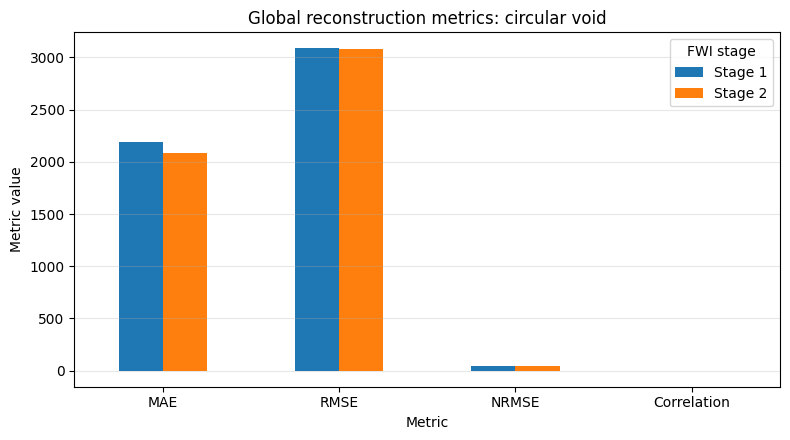

In [1271]:
# ============================================================
# FIGURE 1: GLOBAL RECONSTRUCTION METRICS
# ============================================================

metrics_to_plot = ["MAE", "RMSE", "NRMSE", "Correlation"]

plot_df = global_df[
    global_df["Metric short name"].isin(metrics_to_plot)
].copy()

pivot_df = plot_df.pivot(
    index="Metric short name",
    columns="FWI stage",
    values="Value"
)

pivot_df = pivot_df.loc[metrics_to_plot]

ax = pivot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Global reconstruction metrics: circular void")
ax.set_ylabel("Metric value")
ax.set_xlabel("Metric")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
save_current_figure("01_global_metrics_circular_void")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/02_void_update_recovery.png


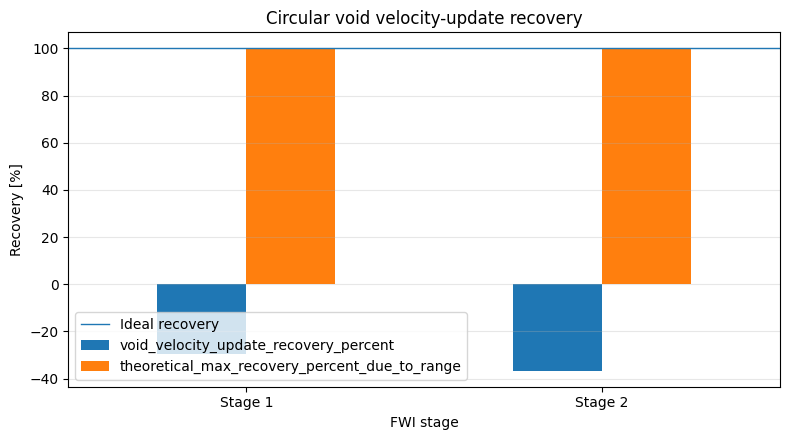

In [1272]:
# ============================================================
# FIGURE 2: VOID AMPLITUDE RECOVERY
# Replaces old band speed error plot.
# ============================================================

recovery_plot_df = void_df[
    [
        "FWI stage",
        "void_velocity_update_recovery_percent",
        "theoretical_max_recovery_percent_due_to_range"
    ]
].copy()

recovery_plot_df = recovery_plot_df.set_index("FWI stage")

ax = recovery_plot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.axhline(100.0, linewidth=1, label="Ideal recovery")

ax.set_title("Circular void velocity-update recovery")
ax.set_xlabel("FWI stage")
ax.set_ylabel("Recovery [%]")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
save_current_figure("02_void_update_recovery")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/03_void_mae_vs_background_mae.png


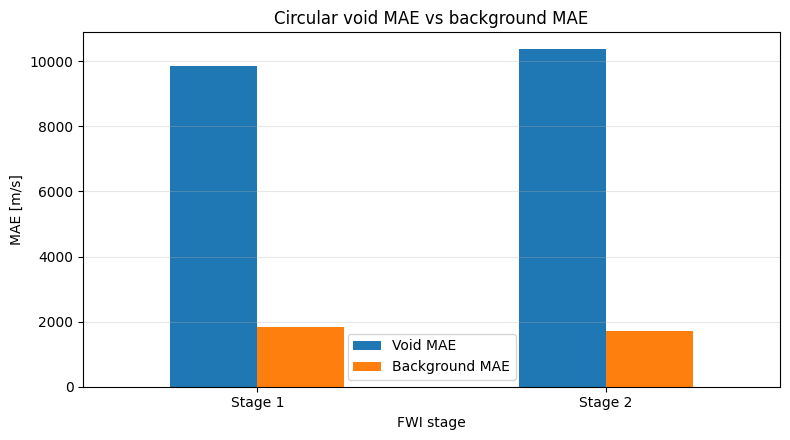

In [1273]:
# ============================================================
# FIGURE 3: VOID ERROR VS BACKGROUND ERROR
# ============================================================

mae_plot_df = void_df[
    [
        "FWI stage",
        "void_MAE_m_per_s",
        "background_MAE_m_per_s"
    ]
].copy()

mae_plot_df = mae_plot_df.set_index("FWI stage")

ax = mae_plot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Circular void MAE vs background MAE")
ax.set_xlabel("FWI stage")
ax.set_ylabel("MAE [m/s]")
ax.grid(axis="y", alpha=0.3)
ax.legend(["Void MAE", "Background MAE"])

plt.tight_layout()
save_current_figure("03_void_mae_vs_background_mae")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/04_void_localization_artifacts.png


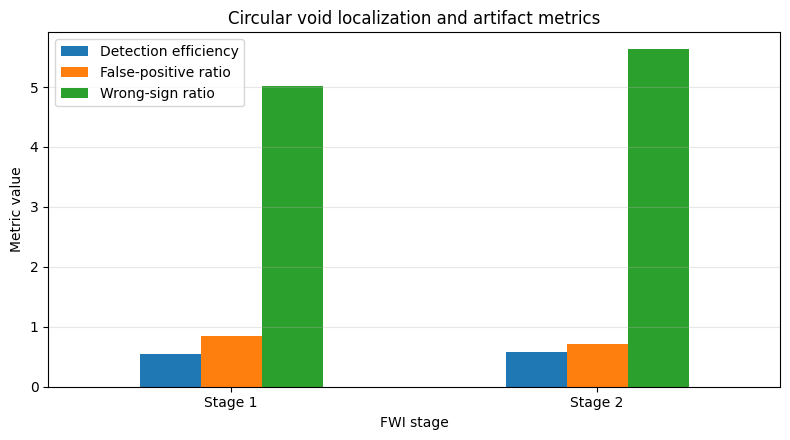

In [1274]:
# ============================================================
# FIGURE 4: VOID LOCALIZATION AND ARTIFACTS
# Replaces old detection-efficiency plot.
# ============================================================

detect_plot_df = void_df[
    [
        "FWI stage",
        "void_detection_efficiency_0_to_1",
        "false_positive_ratio_background_to_void",
        "wrong_sign_ratio_inside_void"
    ]
].copy()

detect_plot_df = detect_plot_df.set_index("FWI stage")

ax = detect_plot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Circular void localization and artifact metrics")
ax.set_xlabel("FWI stage")
ax.set_ylabel("Metric value")
ax.grid(axis="y", alpha=0.3)
ax.legend([
    "Detection efficiency",
    "False-positive ratio",
    "Wrong-sign ratio"
])

plt.tight_layout()
save_current_figure("04_void_localization_artifacts")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/05_void_shape_overlap_metrics.png


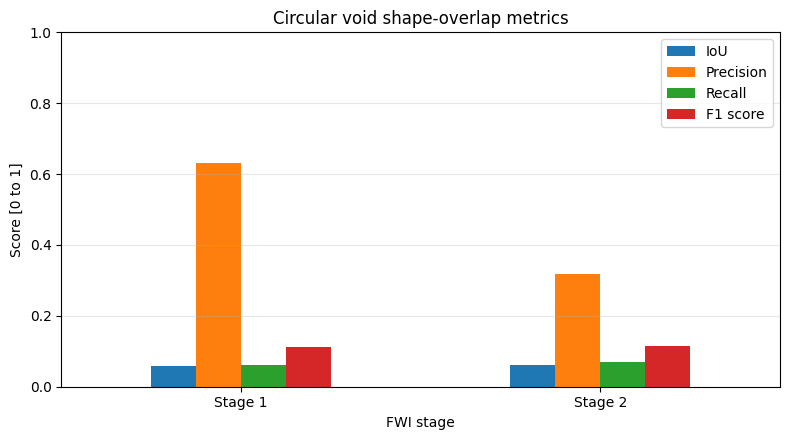

In [1275]:
# ============================================================
# FIGURE 5: VOID SHAPE DETECTION METRICS
# Replaces old boundary-deviation plot.
# ============================================================

shape_plot_df = shape_df[
    [
        "FWI stage",
        "IoU_intersection_over_union",
        "precision_detected_pixels_inside_true_void",
        "recall_true_void_pixels_detected",
        "F1_score"
    ]
].copy()

shape_plot_df = shape_plot_df.set_index("FWI stage")

ax = shape_plot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Circular void shape-overlap metrics")
ax.set_xlabel("FWI stage")
ax.set_ylabel("Score [0 to 1]")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend(["IoU", "Precision", "Recall", "F1 score"])

plt.tight_layout()
save_current_figure("05_void_shape_overlap_metrics")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/06_void_center_radius_error.png


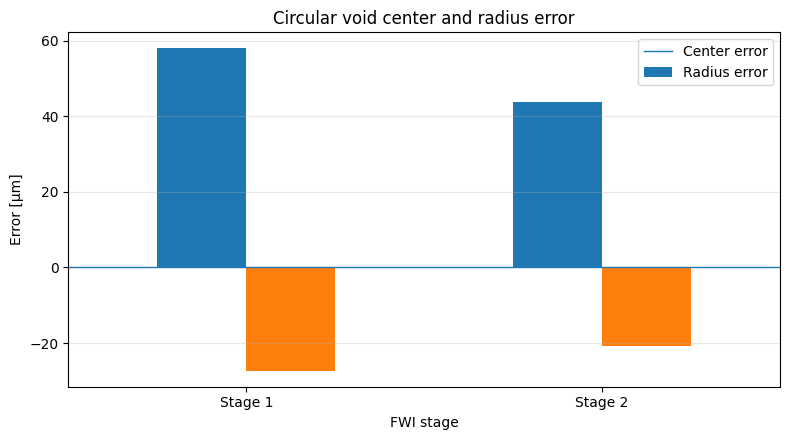

In [1276]:
# ============================================================
# FIGURE 6: VOID CENTER AND RADIUS ERROR
# Replaces old band-position and thickness-change plots.
# ============================================================

shape_error_df = shape_df[
    [
        "FWI stage",
        "center_error_micrometers",
        "radius_error_micrometers"
    ]
].copy()

shape_error_df = shape_error_df.set_index("FWI stage")

ax = shape_error_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.axhline(0, linewidth=1)

ax.set_title("Circular void center and radius error")
ax.set_xlabel("FWI stage")
ax.set_ylabel("Error [µm]")
ax.grid(axis="y", alpha=0.3)
ax.legend(["Center error", "Radius error"])

plt.tight_layout()
save_current_figure("06_void_center_radius_error")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/07_stage2_speed_hist_void_vs_background.png


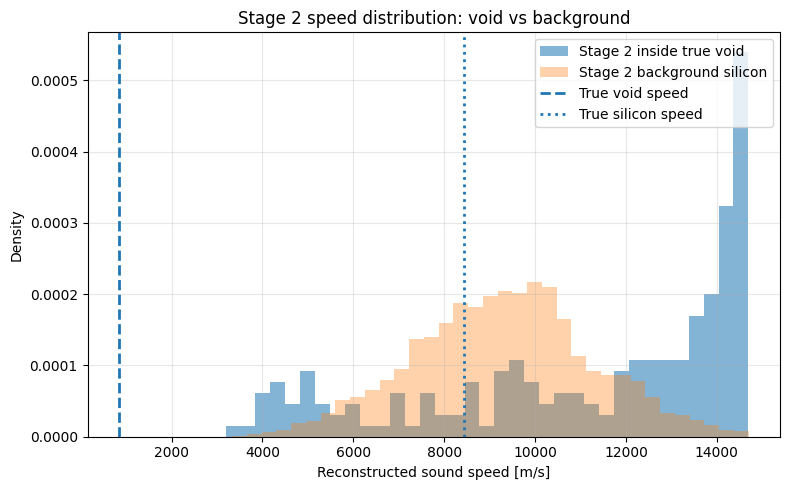

In [1277]:
# ============================================================
# FIGURE 7: SPEED HISTOGRAM INSIDE VOID VS BACKGROUND
# Evidence that shows if reconstructed speeds approach true speeds.
# ============================================================

void_pixels = map_long_df[
    map_long_df["inside_true_circular_void"] == "yes"
].copy()

background_pixels = map_long_df[
    (map_long_df["region_label"] == "silicon_background")
    & (map_long_df["inside_inversion_mask"] == "yes")
].copy()

plt.figure(figsize=(8, 5))

plt.hist(
    void_pixels["stage2_sound_speed_m_per_s"].dropna(),
    bins=35,
    alpha=0.55,
    density=True,
    label="Stage 2 inside true void"
)

plt.hist(
    background_pixels["stage2_sound_speed_m_per_s"].dropna(),
    bins=35,
    alpha=0.35,
    density=True,
    label="Stage 2 background silicon"
)

plt.axvline(
    true_void_speed,
    linewidth=2,
    linestyle="--",
    label="True void speed"
)

plt.axvline(
    si_speed,
    linewidth=2,
    linestyle=":",
    label="True silicon speed"
)

plt.xlabel("Reconstructed sound speed [m/s]")
plt.ylabel("Density")
plt.title("Stage 2 speed distribution: void vs background")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
save_current_figure("07_stage2_speed_hist_void_vs_background")
plt.show()

Saved figure:
fwi_void_20to85_v10_c90_u7590/figures/08_stage2_improvement_summary.png


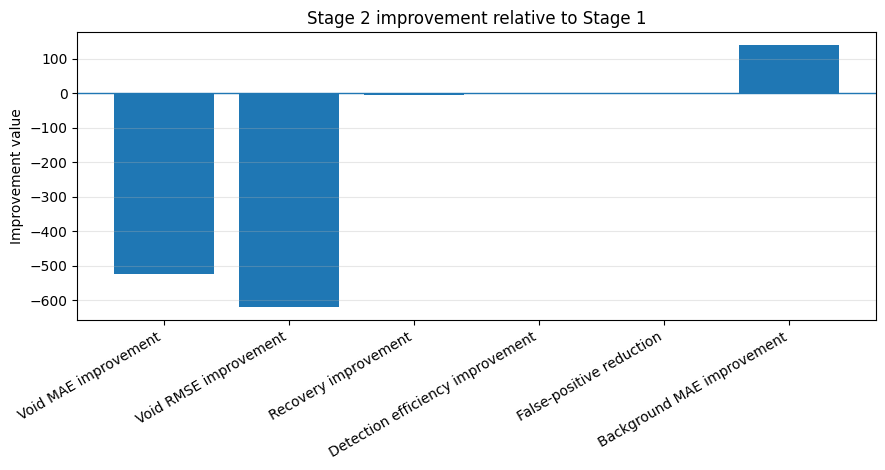

In [1278]:
# ============================================================
# FIGURE 8: STAGE 1 VS STAGE 2 IMPROVEMENT SUMMARY
# ============================================================

improvement_plot_df = pd.DataFrame({
    "Metric": [
        "Void MAE improvement",
        "Void RMSE improvement",
        "Recovery improvement",
        "Detection efficiency improvement",
        "False-positive reduction",
        "Background MAE improvement"
    ],
    "Value": [
        void_improvement_df["Void MAE improvement m/s"].iloc[0],
        void_improvement_df["Void RMSE improvement m/s"].iloc[0],
        void_improvement_df["Recovery percent improvement"].iloc[0],
        void_improvement_df["Detection efficiency improvement"].iloc[0],
        void_improvement_df["False positive reduction"].iloc[0],
        void_improvement_df["Background MAE improvement m/s"].iloc[0],
    ]
})

plt.figure(figsize=(9, 4.8))

plt.bar(
    improvement_plot_df["Metric"],
    improvement_plot_df["Value"]
)

plt.axhline(0, linewidth=1)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Improvement value")
plt.title("Stage 2 improvement relative to Stage 1")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_current_figure("08_stage2_improvement_summary")
plt.show()

In [1279]:
# ============================================================
# FINAL VOID EVIDENCE SUMMARY TABLE
# ============================================================

stage2_void_row = void_df[
    void_df["FWI stage"] == "Stage 2"
].iloc[0]

stage2_shape_row = shape_df[
    shape_df["FWI stage"] == "Stage 2"
].iloc[0]

void_evidence_summary_df = pd.DataFrame([{
    "geometry": "circular_void",

    "void_speed_fraction": void_speed_fraction,
    "void_speed_percent_of_silicon": 100.0 * void_speed_fraction,
    "void_contrast_percent_relative_to_silicon": 100.0 * (1.0 - void_speed_fraction),

    "true_void_speed_m_per_s": true_void_speed,
    "silicon_background_speed_m_per_s": si_speed,
    "required_update_m_per_s": required_update_for_void,

    "stage2_reconstructed_mean_void_speed_m_per_s": stage2_void_row[
        "reconstructed_mean_void_speed_m_per_s"
    ],

    "stage2_void_update_recovery_percent": stage2_void_row[
        "void_velocity_update_recovery_percent"
    ],

    "stage2_void_MAE_m_per_s": stage2_void_row[
        "void_MAE_m_per_s"
    ],

    "stage2_background_MAE_m_per_s": stage2_void_row[
        "background_MAE_m_per_s"
    ],

    "stage2_void_detection_efficiency": stage2_void_row[
        "void_detection_efficiency_0_to_1"
    ],

    "stage2_false_positive_ratio": stage2_void_row[
        "false_positive_ratio_background_to_void"
    ],

    "stage2_wrong_sign_ratio_inside_void": stage2_void_row[
        "wrong_sign_ratio_inside_void"
    ],

    "stage2_IoU": stage2_shape_row[
        "IoU_intersection_over_union"
    ],

    "stage2_precision": stage2_shape_row[
        "precision_detected_pixels_inside_true_void"
    ],

    "stage2_recall": stage2_shape_row[
        "recall_true_void_pixels_detected"
    ],

    "stage2_F1_score": stage2_shape_row[
        "F1_score"
    ],

    "stage2_center_error_micrometers": stage2_shape_row[
        "center_error_micrometers"
    ],

    "stage2_radius_error_micrometers": stage2_shape_row[
        "radius_error_micrometers"
    ],

    "stage2_successful_detection": stage2_void_row[
        "successful_detection"
    ],
}])

void_evidence_summary_csv = os.path.join(
    output_dir,
    "TABLE_final_void_evidence_summary_READABLE.csv"
)

void_evidence_summary_df.to_csv(
    void_evidence_summary_csv,
    index=False
)

display(void_evidence_summary_df)

print("Saved final void evidence summary:")
print(void_evidence_summary_csv)

,geometry,void_speed_fraction,void_speed_percent_of_silicon,void_contrast_percent_relative_to_silicon,true_void_speed_m_per_s,silicon_background_speed_m_per_s,required_update_m_per_s,stage2_reconstructed_mean_void_speed_m_per_s,stage2_void_update_recovery_percent,stage2_void_MAE_m_per_s,...,stage2_void_detection_efficiency,stage2_false_positive_ratio,stage2_wrong_sign_ratio_inside_void,stage2_IoU,stage2_precision,stage2_recall,stage2_F1_score,stage2_center_error_micrometers,stage2_radius_error_micrometers,stage2_successful_detection
0,circular_void,0.1,10.0,90.0,843.3,8433.0,7589.7,11214.865,-36.653168,10371.566,...,0.58582,0.707009,5.63163,0.061674,0.318182,0.071066,0.116183,43.705704,-20.881839,False


Saved final void evidence summary:
fwi_void_20to85_v10_c90_u7590/TABLE_final_void_evidence_summary_READABLE.csv
